In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import fsps
from tqdm import tqdm
from astropy import constants as const
tiny_number = 1e-70

from ceridwen.ssps.ssp_data import SSPData
#from ceridwen.csp.csp import CSPBasis, fnu2flam

T_UNIV = 13.8  # Gyr, age of the universe
N_T = 5     # number of time steps for SFH

def gaussian_burst(tau, center_tau, width_tau, amp=1.0):
    """Gaussian in lookback time, evaluated on tau grid (Gyr)."""
    return amp * jnp.exp(-0.5 * ((tau - center_tau) / width_tau)**2)

t = jnp.linspace(1e-2, T_UNIV, N_T)   # Gyr (avoid exactly 0)
tau = T_UNIV - t                      # lookback time (Gyr)

sfr_bimodal = (gaussian_burst(tau, 0.05, 0.03, 1.0) +
               gaussian_burst(tau, 11.0, 0.8, 0.7))
zh = jnp.full_like(t, -4.3477116)  # constant metallicity (Z=0.02)

ssp_data = SSPData.load('/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/ssp_data.h5')

ssp_data.ssp_flux.shape

(12, 108, 5994)

In [ ]:
"""
Composite Stellar Population (CSP) Module

This module implements the CSP modeling framework for generating synthetic spectra
from complex star formation and metallicity histories. It provides tools for:

- Building CSPs from Simple Stellar Population (SSP) libraries
- Handling time-dependent star formation and metallicity evolution  
- Computing spectral weights through integration of stellar population models
- Supporting both tabular and parametric stellar formation histories

The core algorithm follows the approach of flexible stellar population synthesis,
where CSPs are constructed by weighting and combining SSP spectra across age
and metallicity grids based on the input star formation and chemical enrichment
histories.

Key classes:
    CSPBasis: Main class for CSP spectrum generation and weight calculation

Key functions:
    add_sfh: Add star formation history to CSP model
    add_zh: Add metallicity evolution history to CSP model  
    intsfwght: Core integration function for stellar formation weights
"""

# JAX imports for high-performance numerical computing
import jax.numpy as jnp  # JAX's numpy-compatible array operations
from jax import jit, vmap      # Just-in-time compilation decorator for performance
from ceridwen.dust import Dust  # Import Dust model for handling dust attenuation
from ceridwen.dust import DustEmission
from ceridwen.neb import NebularModel
import pprint
import astropy.constants as const

def fnu2flam(lam, fnu):
    """Convert f_nu [erg/s/cm^2/Hz] to f_lambda [erg/s/cm^2/Å]."""
    c = 2.998e18  # Å/s
    return c * fnu / (lam**2)

def add_zh(zh, lookback_time=None, forward_time=None, tuniv=13.8):
    """
    Add a star formation history (SFH) for a CSP.
    Parameters:
        zh (array-like): The metallicity at the given ages.
            Example: [0.1, 0.2, 0.3, 0.4]
        
        lookback_time (array-like, optional): Lookback times for the SFH in Gyr.
            Example: [1.0, 2.0, 3.0, 4.0]
        
        forward_time (array-like, optional): Forward times (age of the universe) for the SFH in Gyr.
            Example: [9.8, 10.8, 11.8, 12.8]
        
        tuniv (float, default 13.8): The age of the stellar population (in Gyr) for which to obtain a spectrum.
            Default: 13.8 Gyr

    Returns:
        tuple: A tuple containing:
            - sfh (jnp.ndarray): The star formation history array.
            Example output: jnp.array([0.1, 0.2, 0.3, 0.4])
            
            - sfh_times (jnp.ndarray): The corresponding times (lookback or forward) for the SFH.
            Example output with lookback_time: jnp.array([1.0, 2.0, 3.0, 4.0])
            Example output with forward_time: jnp.array([1.0, 2.0, 3.0, 4.0]) (computed as tuniv - forward_time)

    Usage:
        >>> add_sfh(sfh=[0.1, 0.2, 0.3, 0.4], lookback_time=[1.0, 2.0, 3.0, 4.0])
        >>> add_sfh(sfh=[0.1, 0.2, 0.3, 0.4], forward_time= [9.8, 10.8, 11.8, 12.8])
    """
    # Convert metallicity history to JAX array for efficient computation
    zh = jnp.array(zh)  # Ensure zh is a JAX array

    # Process time input - either lookback time (time before present) or forward time (age of universe)
    if lookback_time is not None:
        print('lookback time')  # Debug output for time mode
        lookback_time = jnp.array(lookback_time)
        # Convert from Gyr to years for internal calculations
        zh_times = lookback_time*1e9  
    elif forward_time is not None:
        print('forward time')  # Debug output for time mode  
        forward_time = jnp.array(forward_time)
        # Convert forward time to lookback time: lookback = tuniv - forward_time
        zh_times = tuniv*1e9 - forward_time*1e9  # Compute lookback time from forward time  
        print(zh_times)  # Debug output for computed times
    else:
        # Neither time specification provided - this is an error condition
        raise ValueError("Either 'lookback_time' or 'forward_time' must be provided.")
    
    # Note: This condition seems incorrect - zh_times should never be None at this point
    if zh_times != None:
        print('No times added for metallicity history, use lookback_time or forward_time of SFH')
    
    # Validate that metallicity and time arrays have consistent dimensions
    if zh.shape != zh_times.shape:
        raise ValueError(
            f"Shape mismatch: zh has shape {zh.shape}, but zh_times has shape {zh_times.shape}."
        )
    
    return zh, zh_times


def add_sfh(sfh, lookback_time=None, forward_time=None, tuniv=13.8):
    """
    Add a star formation history (SFH) for a CSP.
    Parameters:
        sfh (array-like): The star formation rate in solar masses per year at the given ages.
            Example: [0.1, 0.2, 0.3, 0.4]
        
        lookback_time (array-like, optional): Lookback times for the SFH in Gyr.
            Example: [1.0, 2.0, 3.0, 4.0]
        
        forward_time (array-like, optional): Forward times (age of the universe) for the SFH in Gyr.
            Example: [9.8, 10.8, 11.8, 12.8]
        
        tuniv (float, default 13.8): The age of the stellar population (in Gyr) for which to obtain a spectrum.
            Default: 13.8 Gyr

    Returns:
        tuple: A tuple containing:
            - sfh (jnp.ndarray): The star formation history array.
            Example output: jnp.array([0.1, 0.2, 0.3, 0.4])
            
            - sfh_times (jnp.ndarray): The corresponding times (lookback or forward) for the SFH.
            Example output with lookback_time: jnp.array([1.0, 2.0, 3.0, 4.0])
            Example output with forward_time: jnp.array([1.0, 2.0, 3.0, 4.0]) (computed as tuniv - forward_time)

    Usage:
        >>> add_sfh(sfh=[0.1, 0.2, 0.3, 0.4], lookback_time=[1.0, 2.0, 3.0, 4.0])
        >>> add_sfh(sfh=[0.1, 0.2, 0.3, 0.4], forward_time= [9.8, 10.8, 11.8, 12.8])
    """
    # Convert star formation history to JAX array for efficient computation
    sfh = jnp.array(sfh)  # Ensure sfh is a JAX array

    # Process time input - either lookback time (time before present) or forward time (age of universe)
    if lookback_time is not None:
        print('lookback time')  # Debug output for time mode
        lookback_time = jnp.array(lookback_time)
        # Convert from Gyr to years for internal calculations  
        sfh_times = lookback_time*1e9  

    elif forward_time is not None:
        print('forward time')  # Debug output for time mode
        forward_time = jnp.array(forward_time)
        # Convert forward time to lookback time: lookback = tuniv - forward_time
        sfh_times = tuniv*1e9 - forward_time*1e9  # Compute lookback time from forward time  
        print(sfh_times)  # Debug output for computed times
    else:
        # Neither time specification provided - this is an error condition
        raise ValueError("Either 'lookback_time' or 'forward_time' must be provided.")
    
    # Validate that star formation rate and time arrays have consistent dimensions
    if sfh.shape != sfh_times.shape:
        raise ValueError(
            f"Shape mismatch: sfh has shape {sfh.shape}, but sfh_times has shape {sfh_times.shape}."
        )
    
    
    return sfh, sfh_times

@jit
def intsfwght(tlimhi, tlimlo, a_broadcasted, sf_slope_broadcasted, logage_broadcasted):
    """
    Compute the integrated star formation weight for CSP modeling.
    
    This function calculates the contribution of stellar populations formed within 
    specific age bins to the overall CSP spectrum. It handles the integration of
    the star formation rate over time intervals, accounting for linear interpolation
    between adjacent time points.
    
    The integration accounts for:
    - Linear interpolation of SFR between time bins (sf_slope term)
    - Proper weighting by formation time and current age
    - Log-linear time scaling typical in stellar population models
    
    Args:
        tlimhi: Upper integration limit in log(age) (younger ages)
        tlimlo: Lower integration limit in log(age) (older ages) 
        a_broadcasted: Linear term coefficient for SFH interpolation
        sf_slope_broadcasted: Slope term for linear SFH interpolation
        logage_broadcasted: Log age of SSP bin being weighted
        
    Returns:
        intsfwght: Integrated star formation weight for the age interval
    """
    # Natural log conversion factor (log10(e)) for mathematical convenience
    loge = jnp.log10(jnp.e)

    # Convert log ages back to linear scale for integration calculations
    exp_tlimlo = 10**tlimlo  # Shape: (i, j) - Linear age at lower limit (older)
    exp_tlimhi = 10**tlimhi  # Shape: (i, j) - Linear age at upper limit (younger)  
    exp_tlimlo_squared = exp_tlimlo**2  # Shape: (i, j) - Squared for quadratic terms
    exp_tlimhi_squared = exp_tlimhi**2  # Shape: (i, j) - Squared for quadratic terms

    # Compute star formation weight at lower integration limit (older ages)
    # b1: Linear term contribution at older boundary
    b1 = a_broadcasted * exp_tlimlo * (logage_broadcasted - tlimlo + loge)
    # c1: Quadratic term contribution from SFH slope at older boundary  
    c1 = sf_slope_broadcasted * exp_tlimlo_squared / 2 * (logage_broadcasted - tlimlo + loge / 2)
    sfwght_lo = b1 + c1  # Total weight contribution at older boundary

    # Compute star formation weight at upper integration limit (younger ages)
    # b2: Linear term contribution at younger boundary
    b2 = a_broadcasted * exp_tlimhi * (logage_broadcasted - tlimhi + loge)
    # c2: Quadratic term contribution from SFH slope at younger boundary
    c2 = sf_slope_broadcasted * exp_tlimhi_squared / 2 * (logage_broadcasted - tlimhi + loge / 2)
    sfwght_hi = b2 + c2  # Total weight contribution at younger boundary

    # Fundamental theorem of calculus: integrated weight = upper_limit - lower_limit
    intsfwght = sfwght_hi - sfwght_lo
    return intsfwght


In [ ]:
csp = CSPBasis(ssp_data, theta_dict={'lookback_time': tau, 'sfh': sfr_bimodal, 'zh': zh}, zh_const=False, verbose = True, add_dust = False, add_neb=False, sps_home='/Users/amanda/Prospector/fsps')
theta_new = jnp.array(csp.theta_init.at[csp.zh_idx].set(jnp.linspace(4.4904351e-05, 4.4904351e-02, N_T)))
theta_new2 = jnp.array(csp.theta_init.at[csp.zh_idx].set(jnp.full_like(sfr_bimodal, 4.4904351e-02)))

spec3 = csp.predict(theta_new)
print(spec3)
print('-----------------')
#spec4 = csp.predict(theta_new2)
#print(jnp.sum(csp.m1))
#print(jnp.sum(csp.m2))
#print(spec4)

{'dust_idx': [10],
 'sfh': [0.0015995980938896537,
         0.49936723709106445,
         1.3417476338872802e-06,
         3.1028850171268253e-20,
         0.24935215711593628],
 'sfh_idx': [0, 1, 2, 3, 4],
 'sfh_times': [13790000128.0, 10342500352.0, 6895000064.0, 3447500288.0, 0.0],
 'theta_init': [0.0015995980938896537,
                0.49936723709106445,
                1.3417476338872802e-06,
                3.1028850171268253e-20,
                0.24935215711593628,
                -4.347711563110352,
                -4.347711563110352,
                -4.347711563110352,
                -4.347711563110352,
                -4.347711563110352,
                0.20000000298023224],
 'zh_idx': [5, 6, 7, 8, 9]}
Get spectrum with no dust attenuation, dust emission, or nebular emission
[3.0637927e-13 3.3446341e-13 4.2382029e-13 ... 3.4507461e-13 3.3872368e-13
 3.3244073e-13]
-----------------


In [666]:
import jax.numpy as jnp
from jax import vmap, lax
from functools import partial
from collections import defaultdict
from sedpy_jax.attenuation_dust import ATTENUATION_LAWS


import inspect
from typing import Callable, Sequence


class Dust:
    """
    JAX-compatible modular dust model that supports multiple attenuation laws per bin.

    Use this to compute attenuation curves given a binning in stellar age
    and a choice of fixed attenuation law per bin. Parameter fitting
    is only applied to the `fit_params` dictionary passed at runtime.

    Call `Dust.describe_attenuation_laws()` to list all available models.
    """

    def __init__(self, bin_edges = [(-jnp.inf, -1.97)], laws = ['powerlaw']):
        """
        Parameters:
            bin_edges (list of tuple): Age bins in Gyr.
            laws (list of str): Attenuation law names (e.g., 'smc', 'kriek_conroy') for each bin.
        """
        assert len(bin_edges) == len(laws), "Must have one dust law per bin"
        self.bin_edges = jnp.array(bin_edges)
        self.num_bins = len(bin_edges)
        self.laws = laws

        self.law_names_resolved = []
        law_name_counter = defaultdict(int)
        law_occurrences = {name: laws.count(name) for name in set(laws)}

        self.law_funcs = []
        self.law_params = []

        for name in laws:
            count = law_name_counter[name]
            law_name_counter[name] += 1

            law_entry = ATTENUATION_LAWS[name]
            base_func = law_entry["func"]
            defaults = law_entry.get("defaults", {})
            params = law_entry.get("params", {})
            doc = law_entry.get("doc", "")

            if law_occurrences[name] == 1:
                # Only used once → keep original name and function
                resolved_name = name
                func = base_func
                param_dict = self._get_law_params(name)
            else:
                # Used multiple times → rename function and parameters
                number = count + 1
                resolved_name = f"{name}{number}"
                func = modify_function(base_func, number, defaults)

                # Register modified version
                ATTENUATION_LAWS[resolved_name] = {
                    "func": func,
                    "defaults": {f"{k}{number}": v for k, v in defaults.items()},
                    "params": {f"{k}{number}": d for k, d in params.items()},
                    "doc": doc
                }

                # Notify user of renaming
                renamed_keys = [f"{k}{number}" for k in defaults.keys()]
                ignored_keys = list(defaults.keys())
                print(f"[dust setup] Law '{name}' is used multiple times. Registered as '{resolved_name}'.")
                print(f"             Use parameters: {', '.join(renamed_keys)}")
                print(f"             Parameters like {', '.join(ignored_keys)} will be ignored.")

                # Rename parameters
                param_dict = self._get_law_params(name)
                param_dict = {f"{k}{number}": v for k, v in param_dict.items()}

            sig = inspect.signature(func)

            # Keep parameters after 'wave' and ignore *args/**kwargs
            ordered_param_names = [
                p.name for p in sig.parameters.values()
                if p.name != "wave"
                and p.kind not in (inspect.Parameter.VAR_POSITIONAL, inspect.Parameter.VAR_KEYWORD)
            ]

            ordered_param_names = [n for n in ordered_param_names if n in param_dict]

            # Fallback: if signature-based detection fails, use param_dict keys (stably sorted)
            if not ordered_param_names:
                ordered_param_names = sorted(param_dict.keys())

            missing = [n for n in ordered_param_names if n not in param_dict]
            if missing:
                raise ValueError(f"Parameters {missing} expected for '{resolved_name}' but not found in param_dict")

            # Create the wrapped function (this is done in Python, not inside jit)
            wrapped_func = make_law_wrapper(func, ordered_param_names)
        

            self.law_names_resolved.append(resolved_name)
            self.law_funcs.append(wrapped_func)
            self.law_params.append(param_dict)

    def _get_law_fn(self, name):
        try:
            return ATTENUATION_LAWS[name]["func"]
        except KeyError:
            raise ValueError(f"Unknown attenuation law: '{name}'. Please add '{name}' to the sedpy_jax.attenuation module, as a function and as an entry in the ATTENUATION_LAWS dictionary.")
    
    def _get_law_params(self, name):
        try:
            return ATTENUATION_LAWS[name]["params"]
        except KeyError:
            raise ValueError(f"Unknown attenuation law: '{name}'. Please add '{name}' to the sedpy_jax.attenuation module, as a function and as an entry in the ATTENUATION_LAWS dictionary.")
        
    def __repr__(self):
        def format_array(arr):
            return "\n    " + "\n    ".join(map(str, arr))

        info = [
            "Dust Model Configuration",
            "=" * 60,
            f"Number of bins          : {self.num_bins}",
            f"Bin edges (Gyr)         : {format_array(self.bin_edges)}",
            f"Dust laws               : {', '.join(self.laws)}",
            f"Dust parameters        : {', '.join(map(str, self.law_params))}",
            "-" * 60,
        ]

        for i, lawname in enumerate(self.laws):
            lawinfo = ATTENUATION_LAWS.get(lawname, {})
            doc = lawinfo.get("doc", "No description.")
            defaults = lawinfo.get("defaults", {})
            params = lawinfo.get("params", {})
            info.append(f"Bin {i} → {lawname}")
            info.append(f"  Description: {doc}")
            for p, d in params.items():
                info.append(f"    {p:10s}: {d}")
            info.append(f"  Defaults: {defaults}")
            info.append("-" * 60)

        return "\n".join(info)


    def compute_attenuation(self, wave, fit_params):
        """
        Compute bin-wise attenuation curves using the provided parameters.

        Parameters:
            wave (jnp.ndarray): Wavelength array in Angstroms.
            fit_params (NamedTuple): Parameters for the attenuation laws.
        Returns:
            jnp.ndarray: shape (num_bins, len(wave)) attenuation per bin
        """

        def curve_fn(i, wave):
            return lax.switch(i, self.law_funcs, wave, fit_params)

        curves = vmap(curve_fn, in_axes=(0, None))(jnp.arange(self.num_bins), wave)
        return curves

    def display(self, fit_params=None):
        """
        Display the attenuation curves for each bin using matplotlib.
        Returns:
            fig, ax: Matplotlib figure and axis objects.
        """
        import matplotlib.pyplot as plt
        wave = jnp.linspace(0, 10000, 1000)

        if fit_params is None:
            fit_params = self.get_default_fit_params()

        curves = self.compute_attenuation(wave, fit_params=fit_params)
        fig, ax = plt.subplots()

        for i in range(len(curves)):
            law = self.law_names_resolved[i]
            t_start, t_end = self.bin_edges[i]
            ax.plot(wave, curves[i], label=f"Bin {i+1}: {law} ({t_start:.0f}–{t_end:.0f} Myr)")

        ax.set_xlabel("Wavelength (Angstroms)")
        ax.set_ylabel("Attenuation")
        ax.set_yscale("log")
        ax.legend()
        plt.show()
        return fig, ax
    
    @staticmethod
    def describe_attenuation_laws():
        """
        Print all available dust laws with descriptions and parameter metadata.
        """
        print("=" * 70)
        print("Available Dust Attenuation Laws in sedpy_jax:\n")
        for name, info in ATTENUATION_LAWS.items():
            print(f"• {name}")
            print(f"  Description: {info.get('doc', 'No description.')}")
            print("  Parameters:")
            for param, desc in info.get("params", {}).items():
                print(f"    {param:12s}: {desc}")
            print("-" * 70)

   

    def get_default_fit_params(self):
        from typing import NamedTuple, Any
        """
        Return a NamedTuple of default fit parameters based on chosen dust laws.
        Returns:
            NamedTuple: e.g. FitParams(tau_smc1=..., tau_smc2=..., dust_index=...)
        """
        defaults = {}

        for law in self.law_names_resolved:
            for v, p in ATTENUATION_LAWS[law].get("defaults", {}).items():
                defaults[v] = p

        # Dynamically create a NamedTuple class with fields matching defaults
        FitParams = NamedTuple("FitParams", [(k, Any) for k in defaults.keys()])
        return FitParams(**defaults)
    
    def get_param_names(self):
        """
        Return a list of all parameter names used in the dust laws.
        Returns:
            list of str: Parameter names.
        """
        param_names = []
        for law in self.law_names_resolved:
            param_names.extend(ATTENUATION_LAWS[law].get("params", {}).keys())
        return param_names


def make_law_wrapper(f, param_names):
    """Return a JAX‑traceable wrapper that extracts given params from a NamedTuple."""
    def wrapped(wave, fit_params):
        args = tuple(getattr(fit_params, name) for name in param_names)
        return f(wave, *args)
    return wrapped


# In case the same dust law is applied multiple times, this function takes care of the renaming.

def modify_function(func, number, defaults_dict=None):
    import inspect

    func_name = func.__name__
    sig = inspect.signature(func)

    new_func_name = f"{func_name}{number}"

    new_params = []
    call_params = []
    original_names = []
    for name, param in sig.parameters.items():
        if param.kind == param.VAR_KEYWORD:
            continue
        new_name = f"{name}{number}" if name != "wave" else f"wave"
        original_names.append(name)

        if param.default is not inspect.Parameter.empty:
            default_val = repr(param.default)
        elif defaults_dict and name in defaults_dict:
            default_val = repr(defaults_dict[name])
        else:
            default_val = None

        if default_val is not None:
            new_params.append(f"{new_name}={default_val}")
        else:
            new_params.append(new_name)

        call_params.append(f"{name}={new_name}")

    arg_str = ", ".join(new_params + ["**kwargs"])
    call_str = f"{func_name}({', '.join(call_params)}, **filtered_kwargs)"

    func_def = f"""
        def {new_func_name}({arg_str}):
            filtered_kwargs = {{k: v for k, v in kwargs.items() if k not in {original_names!r}}}
            return {call_str}
        """

    local_ns = {func_name: func}
    exec(func_def, local_ns)
    return local_ns[new_func_name]


class DiffuseDust(Dust):
    def __init__(self, law="kriek_conroy"):
        """
        A simplified dust model that applies one dust law to all ages (bin spans all time).
        
        Parameters:
            law (str): Name of the attenuation law (must be in ATTENUATION_LAWS).
        """
        # Initialize parent class with one bin spanning all time
        super().__init__(bin_edges=[(-jnp.inf, jnp.inf)], laws=[law])

        # Rename all parameters in the single bin to use prefix 'diffuse_'
        old_name = self.law_names_resolved[0]
        param_dict = self.law_params[0]

        # Create remapped version
        self.diffuse_param_map = {}
        renamed_param_dict = {}
        for k, v in param_dict.items():
            new_k = f"diffuse_{k}"
            renamed_param_dict[new_k] = v
            self.diffuse_param_map[new_k] = k

        # Replace the first bin’s param dict with the renamed version
        self.law_params[0] = renamed_param_dict

        # Also update the wrapped function to use the renamed keys
        func = ATTENUATION_LAWS[old_name]["func"]
        sig = inspect.signature(func)

        param_names = [
            f"diffuse_{p.name}" for p in sig.parameters.values()
            if p.name != "wave"
            and p.kind not in (inspect.Parameter.VAR_POSITIONAL, inspect.Parameter.VAR_KEYWORD)
        ]

        wrapped_func = make_law_wrapper(func, param_names)
        self.law_funcs[0] = wrapped_func

        # Save param name list for reference
        self.dust_param_names = param_names

    def get_default_params(self):
        """
        Return a NamedTuple of default fit parameters, with names prefixed by 'diffuse_'.
        """
        from typing import NamedTuple, Any

        defaults = {}
        law = self.law_names_resolved[0]
        for k, v in ATTENUATION_LAWS[law].get("defaults", {}).items():
            defaults[f"diffuse_{k}"] = v

        FitParams = NamedTuple("DiffuseParams", [(k, Any) for k in defaults.keys()])
        return FitParams(**defaults)

    def get_param_names(self):
        return list(self.law_params[0].keys())

    def __repr__(self):
        base_repr = super().__repr__()
        return base_repr.replace("Dust Model Configuration", "Diffuse Dust Model Configuration")

In [337]:
ddust = DiffuseDust("kriek_conroy")
fit_params = ddust.get_default_params()
print(ddust)
print(fit_params)

Diffuse Dust Model Configuration
Number of bins          : 1
Bin edges (Gyr)         : 
    [-inf  inf]
Dust laws               : kriek_conroy
Dust parameters        : {'diffuse_tau_kc': 'Amplitude of attenuation at 5500 Å', 'diffuse_dust_index': 'Power-law slope around the Calzetti curve'}
------------------------------------------------------------
Bin 0 → kriek_conroy
  Description: Flexible attenuation curve with variable slope around Calzetti, Kriek & Conroy (2013).
    tau_kc    : Amplitude of attenuation at 5500 Å
    dust_index: Power-law slope around the Calzetti curve
  Defaults: {'tau_kc': 1.0, 'dust_index': 0.0}
------------------------------------------------------------
DiffuseParams(diffuse_tau_kc=1.0, diffuse_dust_index=0.0)


In [336]:
atten = ddust.compute_attenuation(csp.wave, fit_params = fit_params)

meoq


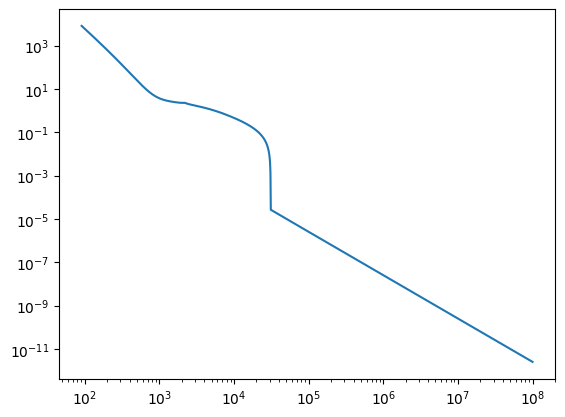

In [310]:
plt.loglog(csp.wave, atten[0])

In [205]:
dust = Dust(bin_edges=[(-jnp.inf, -1.97), (-1.97, 0.0), (0.0, 1)], laws=['smc', 'smc', 'kriek_conroy'])
print(dust)

[dust setup] Law 'smc' is used multiple times. Registered as 'smc1'.
             Use parameters: tau_smc1
             Parameters like tau_smc will be ignored.
[dust setup] Law 'smc' is used multiple times. Registered as 'smc2'.
             Use parameters: tau_smc2
             Parameters like tau_smc will be ignored.
Dust Model Configuration
Number of bins          : 3
Bin edges (Gyr)         : 
    [ -inf -1.97]
    [-1.97  0.  ]
    [0. 1.]
Dust laws               : smc, smc, kriek_conroy
Dust parameters        : {'tau_smc1': 'Optical depth at 1500 Å'}, {'tau_smc2': 'Optical depth at 1500 Å'}, {'tau_kc': 'Amplitude of attenuation at 5500 Å', 'dust_index': 'Power-law slope around the Calzetti curve'}
------------------------------------------------------------
Bin 0 → smc
  Description: SMC extinction curve from Gordon et al. (2003), appropriate for low-metallicity environments.
    tau_smc   : Optical depth at 1500 Å
  Defaults: {'tau_smc': 1.0}
-----------------------------------

In [206]:
print(dust.get_default_fit_params()._asdict())
print(dust.get_param_names())

{'tau_smc1': 1.0, 'tau_smc2': 1.0, 'tau_kc': 1.0, 'dust_index': 0.0}
['tau_smc1', 'tau_smc2', 'tau_kc', 'dust_index']


In [207]:
fit_params = dust.get_default_fit_params()

attn = dust.compute_attenuation(wave = csp.wave, fit_params = fit_params)

meoq


In [209]:
def run_attenuation(wave, fit_params):
    return dust.compute_attenuation(wave, fit_params)

attn_jit = jit(run_attenuation)
attn = attn_jit(csp.wave, fit_params)

meoq


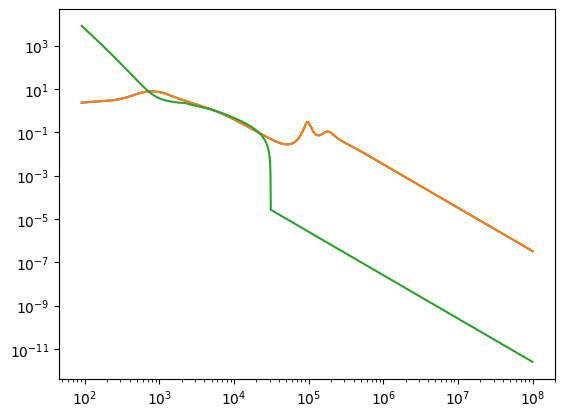

In [172]:
plt.loglog(csp.wave, attn[0])
plt.loglog(csp.wave, attn[1])
plt.loglog(csp.wave, attn[2])

In [ ]:
def __init__(self, SSPData, theta_dict = {'lookback_time': 13.8 - jnp.linspace(1e-2, 13.8, 100)}, tuniv = 13.8, tiny_logt = -70, zh_const = False,
                 add_neb = True, init_neb_params = {"isoc_type": "mist", "cloudy_dust": True}, 
                 add_dust = True, add_diffuse_dust = True, add_dust_emission = False, sps_home = '/Users/amanda/Prospector/fsps',
                 init_dust_params = {'bin_edges': [(-jnp.inf, -1.97)], 'laws': ['powerlaw']},
                 diffuse_law = 'kriek_conroy', verbose = True, **kwargs):
        """
        Initialize CSPBasis with the given SSPData object and age bounds from gal_t_table.
        
        Parameters:
            SSPData: An object holding SSP data (ages, metallicities, wavelengths, fluxes).
            tuniv: Age of the universe in Gyr (default: 13.8 Gyr)
            tiny_logt: Minimum lookback time in log(years) to prevent numerical issues
            **kwargs: Additional keyword arguments (not used here, but available for future extensions).
        """
        
        # Extract and convert SSP data to JAX arrays for efficient computation
        self.flux = jnp.array(SSPData.ssp_flux)        # SSP flux array: shape (n_metallicity, n_age, n_wavelength)
        self.wave = jnp.array(SSPData.ssp_wave)        # Wavelength grid in Angstroms: shape (n_wavelength,)
        self.ages = jnp.array(SSPData.ssp_lg_age_gyr)  # SSP ages in log10(Gyr): shape (n_age,)
        self.zmet = jnp.array(SSPData.ssp_lgmet)       # SSP metallicities in log10(Z/Zsun): shape (n_metallicity,)
        self.logqq = jnp.array(SSPData.log_qq)         # SSP log10(Q/Qsun): shape (n_age, n_metallicity)

        # Convert log metallicities to linear scale for interpolation calculations
        self.zlegend = 10**jnp.array(SSPData.ssp_lgmet)  # Linear metallicity scale: shape (n_metallicity,)

        # Convert SSP age grid from log(Gyr) to log(yr) for internal time calculations
        # This standardizes time units throughout the CSP calculations
        self.ssp_ages_lgyr = self.ages + 9  # Convert from log(Gyr) to log(yr): log10(Gyr) + log10(1e9) = log10(yr)
        
        # Universe age and numerical precision parameters
        self.tuniv = tuniv        # Age of the Universe in Gyr (cosmological parameter)
        self.tiny_logt = tiny_logt  # Smallest lookback time we accept in log(years) to prevent numerical issues

        self.sps_home = sps_home  # Path to FSPS home directory for stellar population synthesis



        if add_neb:
            self.neb_model = NebularModel(
                sps_home=self.sps_home,
                csp_lambda=self.wave,
                nebular_smooth_init=2,
                smooth_velocity=True,
                mypi = jnp.pi,
                **init_neb_params)

        if add_diffuse_dust:
            self.diff_dust = DiffuseDust(diffuse_law)
            diff_fit_dict = self.diff_dust.get_default_params()._asdict()

            for k, v in diff_fit_dict.items():
                if k not in theta_dict:
                    theta_dict[k] = v

            self.diff_param_names = list(diff_fit_dict.keys())
            self.DiffDustParams = NamedTuple("DiffDustParams", [(name, float) for name in self.diff_param_names])

            def attenuate_dust(wave, theta):
                # binwise
                dust_param_values = tuple(theta[getattr(self, f"{name}_idx")] for name in self.dust_param_names)
                dust_params = self.DustParams(*dust_param_values)
                attn = self.dust_attn.compute_attenuation(wave, dust_params)

                # diffuse
                diffuse_param_values = tuple(theta[getattr(self, f"{name}_idx")] for name in self.diff_param_names)
                diffuse_params = self.DiffDustParams(*diffuse_param_values)
                attn_diffuse = self.diff_dust.compute_attenuation(wave, diffuse_params)

                return attn, attn_diffuse

        elif self.dust_mode == 'binwise':
            def attenuate_dust(wave, theta):
                dust_param_values = tuple(theta[getattr(self, f"{name}_idx")] for name in self.dust_param_names)
                dust_params = self.DustParams(*dust_param_values)
                attn = self.dust_attn.compute_attenuation(wave, dust_params)

                # Dummy diffuse (no attenuation)
                attn_diffuse = jnp.zeros((1, wave.shape[0]))
                return attn, attn_diffuse

        elif self.dust_mode == 'diffuse':
            self.bin_low = jnp.array([-jnp.inf])
            self.bin_high = jnp.array([jnp.inf])
            def attenuate_dust(wave, theta):
                # Dummy binwise (no attenuation)
                attn = jnp.zeros((1, wave.shape[0]))

                # Actual diffuse attenuation
                diffuse_param_values = tuple(theta[getattr(self, f"{name}_idx")] for name in self.diff_param_names)
                diffuse_params = self.DiffDustParams(*diffuse_param_values)
                attn_diffuse = self.diff_dust.compute_attenuation(wave, diffuse_params)

                return attn, attn_diffuse


        # Initialize Dust model with provided parameters
            self.dust_attn = Dust(**init_dust_params)
            self.bin_low = jnp.array([edge[0] for edge in self.dust_attn.bin_edges])
            self.bin_high = jnp.array([edge[1] for edge in self.dust_attn.bin_edges])
            
            dust_fit_dict = self.dust_attn.get_default_fit_params()._asdict()
            for k, v in dust_fit_dict.items():
                if k not in theta_dict:
                    theta_dict[k] = v

            self.dust_param_names = list(dust_fit_dict.keys())
            self.DustParams = NamedTuple("DustParams", [(name, float) for name in self.dust_param_names])

            print(self.DustParams)


        self.attenuate_dust = attenuate_dust

        if add_dust:
            if add_diffuse_dust:
                if add_dust_emission:
                    # Initialize DustEmission model for re-emission of absorbed light
                    self.dust_emi = DustEmission(spec_lambda=self.wave, dust_file=sps_home)
                    if add_neb:
                        print('Get spectrum with dust attenuation, dust emission, and nebular emission')
                        self.get_spectrum = self.get_spectrum_dattn_dem_neb
                    else:
                        print('Get spectrum with dust attenuation and dust emission, but no nebular emission')
                        self.get_spectrum = self.get_spectrum_dattn_dem_noneb
                else: 
                    if add_neb:
                        print('Get spectrum with dust attenuation, but no dust emission, and with nebular emission')
                        self.get_spectrum = self.get_spectrum_dattn_nodem_neb
                    else:
                        print('Get spectrum with dust attenuation, but no dust emission or nebular emission')
                        self.get_spectrum = self.get_spectrum_dattn_nodem_noneb
            else:
                if add_neb:
                    print('Get spectrum with dust attenuation, but no dust emission, and with nebular emission')
                    self.get_spectrum = self.get_spectrum_dattn_nodem_neb
                else:
                    print('Get spectrum with dust attenuation, but no dust emission or nebular emission')
                    self.get_spectrum = self.get_spectrum_dattn_nodem_noneb
        else:
            if add_neb:
                print('Get spectrum with no dust attenuation, but with nebular emission')
                self.get_spectrum = self.get_spectrum_nodattn_nodem_neb
            else:
                print('Get spectrum with no dust attenuation, dust emission, or nebular emission')
                self.get_spectrum = self.get_spectrum_nodattn_nodem_noneb

        # Initially set the SSP weight calculation method depending on metallicity history    
        if zh_const:
            self.calculate_ssp_weights = self.calculate_ssp_weights_const_zh    
        else:
            self.calculate_ssp_weights = self.calculate_ssp_weights_var_zh


        # Determine Model Structure
        summary = self.initialize_model_structure(theta_dict)
        if verbose:
            pprint.pprint(summary.keys())

        # Generate a list of parameter names ordered by their index in theta
        self.params = []

        for attr in dir(self):
            if attr.endswith('_idx') and not attr.startswith('__'):
                idx = getattr(self, attr)
                if isinstance(idx, jnp.ndarray) and idx.ndim == 1:
                    self.params.append((attr[:-4], idx))  # remove "_idx" from name

        # Sort by the first index so order matches theta vector
        self.params = sorted(self.params, key=lambda x: int(x[1][0]))

In [258]:
zh = 10**np.array([-4.3477116, -4.3477116, -4.3477116, -4.3477116, -4.3477116])

In [645]:
from typing import NamedTuple



class CSPBasis:
    """
    A class to wrap the CSP object, providing the spectrum of a CSP for a given SFH.
    """

    def __init__(self, SSPData, theta_dict = {'lookback_time': 13.8 - jnp.linspace(1e-2, 13.8, 100)}, tuniv = 13.8, tiny_logt = -70, zh_const = False,
                 add_neb = True, init_neb_params = {"isoc_type": "mist", "cloudy_dust": True}, 
                 add_dust = True, add_diffuse_dust = True, add_dust_emission = False, sps_home = '/Users/amanda/Prospector/fsps',
                 init_dust_params = {'bin_edges': [(-jnp.inf, -1.97)], 'laws': ['powerlaw']},
                 diffuse_law = 'kriek_conroy', verbose = True, **kwargs):
        """
        Initialize CSPBasis with the given SSPData object and age bounds from gal_t_table.
        
        Parameters:
            SSPData: An object holding SSP data (ages, metallicities, wavelengths, fluxes).
            tuniv: Age of the universe in Gyr (default: 13.8 Gyr)
            tiny_logt: Minimum lookback time in log(years) to prevent numerical issues
            **kwargs: Additional keyword arguments (not used here, but available for future extensions).
        """
        
        # Extract and convert SSP data to JAX arrays for efficient computation
        self.flux = jnp.array(SSPData.ssp_flux)        # SSP flux array: shape (n_metallicity, n_age, n_wavelength)
        self.wave = jnp.array(SSPData.ssp_wave)        # Wavelength grid in Angstroms: shape (n_wavelength,)
        self.ages = jnp.array(SSPData.ssp_lg_age_gyr)  # SSP ages in log10(Gyr): shape (n_age,)
        self.zmet = jnp.array(SSPData.ssp_lgmet)       # SSP metallicities in log10(Z/Zsun): shape (n_metallicity,)
        self.logqq = jnp.array(SSPData.log_qq)         # SSP log10(Q/Qsun): shape (n_age, n_metallicity)

        # Convert log metallicities to linear scale for interpolation calculations
        self.zlegend = 10**jnp.array(SSPData.ssp_lgmet)  # Linear metallicity scale: shape (n_metallicity,)

        # Convert SSP age grid from log(Gyr) to log(yr) for internal time calculations
        # This standardizes time units throughout the CSP calculations
        self.ssp_ages_lgyr = self.ages + 9  # Convert from log(Gyr) to log(yr): log10(Gyr) + log10(1e9) = log10(yr)
        
        # Universe age and numerical precision parameters
        self.tuniv = tuniv        # Age of the Universe in Gyr (cosmological parameter)
        self.tiny_logt = tiny_logt  # Smallest lookback time we accept in log(years) to prevent numerical issues

        self.sps_home = sps_home  # Path to FSPS home directory for stellar population synthesis



        if add_neb:
            self.neb_model = NebularModel(
                sps_home=self.sps_home,
                csp_lambda=self.wave,
                nebular_smooth_init=2,
                smooth_velocity=True,
                mypi = jnp.pi,
                **init_neb_params)

        
        self.initialize_dust_components(add_dust, add_diffuse_dust, 
                                        add_dust_emission, theta_dict, 
                                        init_dust_params, diffuse_law, 
                                        sps_home)
        if add_dust or add_diffuse_dust:
            self.set_attenuation_function(add_diffuse_dust, add_dust)
        self.configure_spectrum_model(add_dust, add_diffuse_dust,
                                      add_dust_emission, add_neb,
                                      sps_home)
        

        # Initially set the SSP weight calculation method depending on metallicity history    
        if zh_const:
            self.calculate_ssp_weights = self.calculate_ssp_weights_const_zh    
        else:
            self.calculate_ssp_weights = self.calculate_ssp_weights_var_zh


        # Determine Model Structure
        summary = self.initialize_model_structure(theta_dict)
        if verbose:
            pprint.pprint(summary.keys())

        # Generate a list of parameter names ordered by their index in theta
        self.params = []

        for attr in dir(self):
            if attr.endswith('_idx') and not attr.startswith('__'):
                idx = getattr(self, attr)
                if isinstance(idx, jnp.ndarray) and idx.ndim == 1:
                    self.params.append((attr[:-4], idx))  # remove "_idx" from name

        # Sort by the first index so order matches theta vector
        self.params = sorted(self.params, key=lambda x: int(x[1][0]))


        
        def attenuate_with_diffuse(wave, theta):
            # --- Extract bin-based dust parameters
            dust_param_values = tuple(theta[getattr(self, f"{name}_idx")] for name in self.dust_param_names)
            dust_params = self.DustParams(*dust_param_values)
            attn = self.dust_attn.compute_attenuation(wave, dust_params)  # shape (num_bins, len(wave))

            # --- Extract diffuse dust parameters
            diffuse_param_values = tuple(theta[getattr(self, f"{name}_idx")] for name in self.diff_param_names)
            diffuse_params = self.DiffDustParams(*diffuse_param_values)
            attn_diffuse = self.diff_dust.compute_attenuation(wave, diffuse_params)  # shape (1, len(wave))

            return attn, attn_diffuse
        
        self.attenuate_dust = attenuate_with_diffuse



    def set_attenuation_function(self, add_diffuse_dust, add_dust):
        """
        Define and assign the appropriate dust attenuation function based on model configuration.

        Parameters
        ----------
        add_diffuse_dust : bool
            Whether to include diffuse dust attenuation in addition to the primary dust model.
        """

        # --- Case 1: both binwise and diffuse dust are included ---
        if add_diffuse_dust and add_dust: 
            
            def attenuate(wave, theta):
                # binwise
                dust_param_values = tuple(theta[getattr(self, f"{name}_idx")] for name in self.dust_param_names)
                dust_params = self.DustParams(*dust_param_values)
                attn = self.dust_attn.compute_attenuation(wave, dust_params)

                # diffuse
                diffuse_param_values = tuple(theta[getattr(self, f"{name}_idx")] for name in self.diff_param_names)
                diffuse_params = self.DiffDustParams(*diffuse_param_values)
                attn_diffuse = self.diff_dust.compute_attenuation(wave, diffuse_params)

                return attn, attn_diffuse
            
            print("Using combined (binwise + diffuse) dust attenuation.")

        
            # --- Assign the chosen function ---
            #self.attenuate_dust = attenuate


    def initialize_dust_components(
        self,
        add_dust: bool,
        add_diffuse_dust: bool,
        add_dust_emission: bool,
        theta_dict: dict,
        init_dust_params: dict,
        diffuse_law: str,
        sps_home: str,
    ):
        """
        Initialize dust-related models and register their parameters.

        Parameters
        ----------
        add_dust : bool
            Whether to include a time-dependent dust attenuation model.
        add_diffuse_dust : bool
            Whether to include a diffuse dust attenuation component (time-independent).
        add_dust_emission : bool
            Whether to include dust re-emission of absorbed energy.
        theta_dict : dict
            Dictionary of parameter names and initial values (will be updated).
        init_dust_params : dict
            Parameters for initializing the Dust attenuation model.
        diffuse_law : str
            Name of the attenuation law for DiffuseDust.
        sps_home : str
            Path to the FSPS / dust emission data directory.
        """

        # --- 1. Initialize dust attenuation model ---
        if add_dust:
            print("Initializing Dust attenuation model...")
            self.dust_attn = Dust(**init_dust_params)

            # Store attenuation time-bin edges
            self.bin_low = jnp.array([edge[0] for edge in self.dust_attn.bin_edges])
            self.bin_high = jnp.array([edge[1] for edge in self.dust_attn.bin_edges])

            # Register default fit parameters
            dust_fit_dict = self.dust_attn.get_default_fit_params()._asdict()
            for k, v in dust_fit_dict.items():
                if k not in theta_dict:
                    theta_dict[k] = v

            self.dust_param_names = list(dust_fit_dict.keys())
            self.DustParams = NamedTuple(
                "DustParams", [(name, float) for name in self.dust_param_names]
            )

        # --- 2. Initialize diffuse dust model ---
        if add_diffuse_dust:
            print("Initializing DiffuseDust model...")
            self.diff_dust = DiffuseDust(diffuse_law)

            diff_fit_dict = self.diff_dust.get_default_params()._asdict()
            for k, v in diff_fit_dict.items():
                if k not in theta_dict:
                    theta_dict[k] = v

            self.diff_param_names = list(diff_fit_dict.keys())
            self.DiffDustParams = NamedTuple(
                "DiffDustParams", [(name, float) for name in self.diff_param_names]
            )

        # --- 3. Initialize dust emission model ---
        if add_dust_emission:
            if not add_diffuse_dust:
                raise ValueError(
                    "add_dust_emission=True requires add_diffuse_dust=True."
                )
            print("Initializing DustEmission model...")
            self.dust_emi = DustEmission(spec_lambda=self.wave, dust_file=sps_home)

            # Collect default parameters if your DustEmission defines them
            if hasattr(self.dust_emi, "get_default_params"):
                emi_fit_dict = self.dust_emi.get_default_params()._asdict()
                for k, v in emi_fit_dict.items():
                    if k not in theta_dict:
                        theta_dict[k] = v

                self.emi_param_names = list(emi_fit_dict.keys())
                self.DustEmiParams = NamedTuple(
                    "DustEmiParams", [(name, float) for name in self.emi_param_names]
                )

        # --- 4. Summary ---
        print("Dust initialization complete.")
        print(f"Parameters registered: {list(theta_dict.keys())}")

        return theta_dict


    def configure_spectrum_model(self, add_dust, add_diffuse_dust, add_dust_emission, add_neb, sps_home):
        """
        Configure which get_spectrum method to use depending on dust and nebular settings.
        """

        # --- Enforce dependency ---
        if add_dust_emission and not add_diffuse_dust:
            raise ValueError("add_dust_emission=True requires add_diffuse_dust=True.")

        # --- Construct a descriptive key summarizing the configuration ---
        if add_dust_emission:
            base = "dattn_dem"
            message = "Get spectrum with dust attenuation and dust emission"
        elif add_dust:  # includes both binwise-only and diffuse-only attenuation (since both call same methods)
            base = "dattn_only"
            message = "Get spectrum with dust attenuation only"
        else:
            base = "nodust"
            message = "Get spectrum with no dust attenuation"

        # --- Add nebular information ---
        if add_neb:
            key = f"{base}_neb"
            message += " and nebular emission"
        else:
            key = f"{base}_noneb"
            message += " and no nebular emission"

        # --- Map to existing implementations ---
        mapping = {
            "nodust_neb":       self.get_spectrum_nodattn_nodem_neb,
            "nodust_noneb":     self.get_spectrum_nodattn_nodem_noneb,
            "dattn_only_neb":   self.get_spectrum_dattn_nodem_neb,
            "dattn_only_noneb": self.get_spectrum_dattn_nodem_noneb,
            "dattn_dem_neb":    self.get_spectrum_dattn_dem_neb,
            "dattn_dem_noneb":  self.get_spectrum_dattn_dem_noneb,
        }

        # --- Assign the selected function ---
        if key not in mapping:
            raise KeyError(f"No spectrum method implemented for configuration '{key}'")

        print(message)
        self.get_spectrum = mapping[key]

    def initialize_model_structure(self, theta_dict: dict):
        """
        Initializes model structure from a flexible theta_dict.

        Required:
            - 'sfh': jnp.ndarray of shape (n_time,)
            - 'lookback_time': jnp.ndarray of shape (n_time,)

        Optional:
            - Any number of scalar or array parameters (e.g. 'Z', 'zh', 'dust', ...)

        Sets:
            - self.sfh_times : jnp.ndarray (in yr)
            - sfh       : jnp.ndarray
            - self.theta_init: jnp.ndarray (flat vector)
            - self.<param>_idx: indices into theta vector for each parameter
            - self.zh_is_scalar: bool
            - self.n_time: int
        """


        # --- Required base parameters
        self.sfh_times = theta_dict['lookback_time'] * 1e9  # Gyr → yr
        sfh = jnp.atleast_1d(theta_dict['sfh'])
        self.n_time = self.sfh_times.size

        assert sfh.shape == (self.n_time,), "'sfh' must match 'lookback_time' length"
        self.sfh_idx = jnp.arange(self.n_time)

        theta_parts = [sfh]
        current_idx = self.n_time  # start after sfh

        # Track special handling of Z vs. zh
        self.zh_is_scalar = None

        for key, val in theta_dict.items():
            if key in ('sfh', 'lookback_time'):
                continue  # already handled

            arr = jnp.atleast_1d(val)

            if key == 'zh':
                assert arr.shape == (self.n_time,), "'zh' must match 'lookback_time' length"
                setattr(self, f'{key}_idx', jnp.arange(current_idx, current_idx + self.n_time))
                self.zh_is_scalar = False
                current_idx += self.n_time

            elif key == 'Z':
                assert arr.shape == (1,), "'Z' must be a scalar"
                setattr(self, f'{key}_idx', jnp.array([current_idx]))
                self.zh_is_scalar = True
                current_idx += 1

            else:
                # General case: scalar or vector parameters
                arr_shape = arr.shape
                flat_len = arr.size
                setattr(self, f'{key}_idx', jnp.arange(current_idx, current_idx + flat_len))
                current_idx += flat_len

            # Append to flat vector
            theta_parts.append(arr)

        # Final flat parameter vector
        self.theta_init = jnp.concatenate(theta_parts)
        
        summary = {
            'sfh_times': self.sfh_times.tolist(),
            'sfh': sfh.tolist(),
            'theta_init': self.theta_init.tolist(),
        }

        # Dynamically include all *_idx attributes
        for name in dir(self):
            if name.endswith('_idx') and not name.startswith('__'):
                summary[name] = getattr(self, name).tolist()

        return summary
   
    def predict(self, theta):
        spectrum = self.get_spectrum(theta = theta)
        return spectrum

    def __repr__(self):
        """
        Provide a string representation of the CSPBasis object, including
        dust attenuation and dust emission models if present.
        """
        repr_str = (
            f"<CSPBasis Object>\n"
            f"-----------------------------------\n"
            f"Universe Age (tuniv): {self.tuniv} Gyr\n"
            f"Tiny Log Time (tiny_logt): {self.tiny_logt}\n"
            f"Number of SSP Ages: {len(self.ages)}\n"
            f"Number of SSP Metallicities: {len(self.zmet)}\n"
            f"Wavelength Range: {self.wave.min()} - {self.wave.max()} Å\n"
        )

        # SFH
        if hasattr(self, "sfh"):
            repr_str += (
                "Star Formation History:\n"
                f"  SFH Times (lookback): {self.sfh_times}\n"
                f"  SFH Values: {sfh}\n"
            )
        else:
            repr_str += "Star Formation History: Not added yet\n"

        # Spectrum status
        repr_str += "Spectrum: Computed\n" if hasattr(self, "spectrum") else "Spectrum: Not computed yet\n"

        # Dust attenuation (if present)
        if getattr(self, "dust", None) is not None:
            repr_str += f"Dust Model: {repr(self.dust)}\n"
            if hasattr(self, "bin_low") and hasattr(self, "bin_high"):
                repr_str += f"  Dust Bins: {len(self.bin_low)} (low={self.bin_low}, high={self.bin_high})\n"
        else:
            repr_str += "Dust Model: None\n"

        # Dust emission (if present)
        if getattr(self, "emi", None) is not None:
            repr_str += f"Dust Emission: {repr(self.emi)}\n"
        else:
            repr_str += "Dust Emission: None\n"

        return repr_str

 
    def get_spectrum_dattn_dem_neb(self):
        """
        Get the spectrum of the CSP with dust attenuation, dust emission, and nebular emission.
        """
        raise NotImplementedError("This method is not yet implemented.")

    def get_spectrum_dattn_dem_noneb(self):
        """
        Get the spectrum of the CSP with dust attenuation and dust emission, but no nebular emission.
        """
        raise NotImplementedError("This method is not yet implemented.")
    
    def get_spectrum_dattn_nodem_neb(self):
        """
        Get the spectrum of the CSP with dust attenuation and nebular emission, but no dust emission.
        """
        raise NotImplementedError("This method is not yet implemented.")
    
    def get_spectrum_dattn_nodem_noneb(self, theta):
        """
        Get the spectrum of the CSP with dust attenuation, but no dust emission or nebular emission.
        """

        attn, attn_diffuse = self.attenuate_dust(self.wave, theta)

        is_in_bin = (self.ages[:, None] >= self.bin_low[None, :]) & (self.ages[:, None] < self.bin_high[None, :])
        bin_indices = jnp.argmax(is_in_bin, axis=1)
        has_bin = jnp.any(is_in_bin, axis=1)

        atten_matrix = jnp.where(has_bin[:, None], jnp.exp(-attn[bin_indices]), jnp.ones_like(attn[0]))
        dusty_flux = self.flux * atten_matrix[None, :, :]
        weights = self.calculate_ssp_weights(theta)
        spectrum_dust = jnp.sum(weights[:, :, None] * dusty_flux, axis=(0, 1))

        # apply diffuse dust, diffuse dust is not included, this is just multiplying with ones
        attenuated = spectrum_dust * jnp.exp(-attn_diffuse)
        self.spectrum = jnp.reshape(attenuated, (-1,)) / (self.n_time - 1)
        return self.spectrum
    
    def get_spectrum_nodattn_nodem_neb(self):
        """
        Get the spectrum of the CSP with nebular emission, but no dust attenuation or dust emission.
        """
        total_weights = self.calculate_ssp_weights()
        # Compute the spectrum using the total_weights and the nebular model
        # This is a placeholder implementation
        raise NotImplementedError("This method is not yet implemented.")


    def get_spectrum_nodattn_nodem_noneb(self, theta):
        """
        Compute CSP spectrum at fixed metallicity (no dust, no nebular).
        """
        
        total_weights = self.calculate_ssp_weights(theta=theta)
        
        spectrum = jnp.sum(total_weights[:, :, None] * self.flux, axis=(0,1))  # Shape: (n_wave,)
        self.spectrum = spectrum / (self.n_time - 1) # Normalize by the number of time bins

        return self.spectrum
    

    def calculate_ssp_weights_const_zh(self, theta):
        """
        Calculate SSP weights for CSP spectrum generation.
        
        This is the core method that computes how much each SSP (defined by age and metallicity)
        contributes to the final CSP spectrum based on the star formation and metallicity histories.
        
        The algorithm:
        1. Interpolates SFH linearly between time bins
        2. Computes mass formed in each time interval  
        3. Distributes this mass across SSP age bins via integration
        4. Handles metallicity evolution through linear interpolation
        
        Dimensions: i = number of SFH time bins (len(sfh) - 1), j = number of SSP ages (len(ssp_ages_lgyr) - 1)
        
        Returns:
            total_weights: Array of SSP weights, shape depends on metallicity history:
                         - No metallicity history: (1, n_age)
                         - With metallicity history: (n_metallicity, n_age)
        """
        # Ensure SFH values are positive to avoid numerical issues
        sfh = theta[self.sfh_idx]
        sfh = jnp.clip(sfh, 1e-30, None)  # Ensure SFH is non-negative - shape (i+1)

        # === TIME BINNING AND SFH INTERPOLATION SETUP ===
        # Define time intervals from the SFH grid
        t1 = self.sfh_times[1:] # Beginning of time intervals (older times) - shape: (i,)
        t2 = self.sfh_times[:-1] # End of time intervals (younger times) - shape: (i,)

        
        # Compute slope for linear interpolation of SFH between adjacent points
        # This allows smooth SFH evolution within each time bin rather than step functions
        sf_slope = jnp.diff(sfh) / ((t1 - t2) * sfh[1:])  # Shape: (i,) - Normalized SFH slope

        # === TIME CLIPPING AND MASS CALCULATION ===
        # Clip times to physically valid range to avoid extrapolation beyond SSP grid
        tq = jnp.clip(t1, 10**self.tiny_logt, 10**self.ssp_ages_lgyr[-1])  # Shape: (i,) - Clipped older times
        tage = jnp.clip(t2, 10**self.tiny_logt, 10**self.ssp_ages_lgyr[-1]) # Shape: (i,) - Clipped younger times
        sf_trunc = tage - tq  # Shape: (i,) - Effective time interval after clipping


        # Calculate total stellar mass formed in each time interval
        # Accounts for linear SFH variation within the interval via trapezoidal rule
        m2 = (
                sfh[1:]  # SFR at younger edge of interval
                * (1 + sf_slope / 2.0 * (tage + tq - 2 * t1))  # Correction for linear SFH slope
                * sf_trunc  # Multiply by time interval duration
            )  # Shape: (i,) - Total stellar mass formed in each interval

        # Calculate parameters for linear SFH interpolation within integration
        tprime = jnp.maximum(0.0, tage - sf_trunc)  # Shape: (i,) - Time offset for slope calculation
        a = 1 - sf_slope * tprime  # Shape: (i,) - Linear interpolation coefficient


        # SSP-related computations
        ssp_dt = jnp.diff(self.ssp_ages_lgyr)  # Time intervals in SSP (shape: (j,))
        logage_lft = self.ssp_ages_lgyr[1:]    # Left edge of log-age bins (shape: (j,))
        logage_rght = self.ssp_ages_lgyr[:-1]  # Right edge of log-age bins (shape: (j,))


        # Broadcasting integration limits
        tq_broadcasted = jnp.log10(tq)[:, None]  # Expand tq for broadcasting (shape: (i, 1))
        tage_broadcasted = jnp.log10(tage)[:, None]  # Expand tage for broadcasting (shape: (i, 1))


        # Compute integration limits with broadcasting
        tlimlo = jnp.clip(logage_lft[None, :], tq_broadcasted, tage_broadcasted)  # Shape: (i, j)
        tlimhi = jnp.clip(logage_rght[None, :], tq_broadcasted, tage_broadcasted)  # Shape: (i, j)


        # Mask computation
        j_indices = jnp.arange(len(self.ssp_ages_lgyr))  # Indices for SSP bins (shape: (j,))
        jmin = jnp.clip(jnp.searchsorted(self.ssp_ages_lgyr, jnp.log10(t1)) - 1, 0, len(self.ssp_ages_lgyr) - 1)  # Shape: (i,)
        jmax = jnp.clip(jnp.searchsorted(self.ssp_ages_lgyr, jnp.log10(t2)) + 2, 0, len(self.ssp_ages_lgyr) - 1)  # Shape: (i,)


        # Create mask for relevant SSP bins
        mask = (j_indices >= jmin[:, None]) & (j_indices < jmax[:, None])  # Shape: (i, n_time)
        mask_lft = mask[:, 1:]  # Mask for left edges (shape: (i, j))
        mask_rght = mask[:, :-1]  # Mask for right edges (shape: (i, j))

    
        # Broadcast bin edges
        logage_lft_broadcasted = logage_lft[None, :]  # broadcast to (1, j)
        logage_rght_broadcasted = logage_rght[None, :]  # broadcast to (1, j)
 

        a_broadcasted = a[:, None]  # broadcast to (i, 1)
        sf_slope_broadcasted = sf_slope[:, None]  # broadcast to (i, 1)


        # Left weights  
        intsfwght_lft = intsfwght(tlimhi, tlimlo, a_broadcasted, sf_slope_broadcasted, logage_lft_broadcasted) # Shape: (i, j)
        tmp_weights_lft = jnp.zeros_like(intsfwght_lft) - intsfwght_lft / ssp_dt[None, :]  # Shape: (i, j)
        tmp_weights_lft = jnp.where(mask_lft, tmp_weights_lft, 0.0)


        # Right weights
        intsfwght_rght = intsfwght(tlimhi, tlimlo, a_broadcasted, sf_slope_broadcasted, logage_rght_broadcasted)  # Shape: (i, j)
        tmp_weights_rght = jnp.zeros_like(intsfwght_rght) + intsfwght_rght / ssp_dt[None, :]  # Shape: (i, j)
        tmp_weights_rght = jnp.where(mask_rght, tmp_weights_rght, 0.0)


        # Combine left and right weights
        result = jnp.zeros((tmp_weights_lft.shape[0], tmp_weights_lft.shape[1]+1))  # Shape: (i, n_time)
        w1 = result.at[:, :-1].add(tmp_weights_lft).at[:, 1:].add(tmp_weights_rght) # Shape: (i, n_time)

        m1 = jnp.sum(w1, axis=1) #shape (i,)
        
        sfh_weights = w1 * (m2[:, None] / m1[:, None])  # Shape: (i, n_time)
        total_sfh_weights = sfh_weights.sum(axis=0) # Shape: (n_time,)

        # Metallicity handling: constant metallicity case
        target_Z = theta[self.Z_idx] # scalar

        # 1. Find interpolation indices along z-axis
        z_idx = jnp.searchsorted(self.zmet, target_Z, side='left')
        z_idx = jnp.clip(z_idx, 1, len(self.zmet) - 1)

        z1 = self.zmet[z_idx - 1]
        z2 = self.zmet[z_idx]
        w = (target_Z - z1) / (z2 - z1)

        # 2. Prepare zeroed weights cube: (n_z, n_age)
        total_weights = jnp.zeros((len(self.zmet), len(self.ages)))  # (n_z, n_age)

        # 3. Add the weights to bins k and k+1 with linear interpolation
        total_weights = total_weights.at[z_idx - 1].add((1 - w) * total_sfh_weights)
        total_weights = total_weights.at[z_idx].add(w * total_sfh_weights)
        
        self.ssp_weights = total_weights
        self.mass_formed = m2
        self.m1 = m1    
        self.m2 = m2
        self.w1 = w1
        
        return total_weights
    


    def calculate_ssp_weights_var_zh(self, theta):
        """
        Calculate SSP weights for CSP spectrum generation.
        
        This is the core method that computes how much each SSP (defined by age and metallicity)
        contributes to the final CSP spectrum based on the star formation and metallicity histories.
        
        The algorithm:
        1. Interpolates SFH linearly between time bins
        2. Computes mass formed in each time interval  
        3. Distributes this mass across SSP age bins via integration
        4. Handles metallicity evolution through linear interpolation
        
        Dimensions: i = number of SFH time bins (len(sfh) - 1), j = number of SSP ages (len(ssp_ages_lgyr) - 1)
        
        Returns:
            total_weights: Array of SSP weights, shape depends on metallicity history:
                         - No metallicity history: (1, n_age)
                         - With metallicity history: (n_metallicity, n_age)
        """
        
        # Ensure SFH values are positive to avoid numerical issues
        sfh = theta[self.sfh_idx]
        sfh = jnp.clip(sfh, 1e-30, None)  # Ensure SFH is non-negative - shape (i+1)

        # === TIME BINNING AND SFH INTERPOLATION SETUP ===
        # Define time intervals from the SFH grid
        t1 = self.sfh_times[1:] # Beginning of time intervals (older times) - shape: (i,)
        t2 = self.sfh_times[:-1] # End of time intervals (younger times) - shape: (i,)

        
        # Compute slope for linear interpolation of SFH between adjacent points
        # This allows smooth SFH evolution within each time bin rather than step functions
        sf_slope = jnp.diff(sfh) / ((t1 - t2) * sfh[1:])  # Shape: (i,) - Normalized SFH slope

        # === TIME CLIPPING AND MASS CALCULATION ===
        # Clip times to physically valid range to avoid extrapolation beyond SSP grid
        tq = jnp.clip(t1, 10**self.tiny_logt, 10**self.ssp_ages_lgyr[-1])  # Shape: (i,) - Clipped older times
        tage = jnp.clip(t2, 10**self.tiny_logt, 10**self.ssp_ages_lgyr[-1]) # Shape: (i,) - Clipped younger times
        sf_trunc = tage - tq  # Shape: (i,) - Effective time interval after clipping


        # Calculate total stellar mass formed in each time interval
        # Accounts for linear SFH variation within the interval via trapezoidal rule
        m2 = (
                sfh[1:]  # SFR at younger edge of interval
                * (1 + sf_slope / 2.0 * (tage + tq - 2 * t1))  # Correction for linear SFH slope
                * sf_trunc  # Multiply by time interval duration
            )  # Shape: (i,) - Total stellar mass formed in each interval

        # Calculate parameters for linear SFH interpolation within integration
        tprime = jnp.maximum(0.0, tage - sf_trunc)  # Shape: (i,) - Time offset for slope calculation
        a = 1 - sf_slope * tprime  # Shape: (i,) - Linear interpolation coefficient


        # SSP-related computations
        ssp_dt = jnp.diff(self.ssp_ages_lgyr)  # Time intervals in SSP (shape: (j,))
        logage_lft = self.ssp_ages_lgyr[1:]    # Left edge of log-age bins (shape: (j,))
        logage_rght = self.ssp_ages_lgyr[:-1]  # Right edge of log-age bins (shape: (j,))


        # Broadcasting integration limits
        tq_broadcasted = jnp.log10(tq)[:, None]  # Expand tq for broadcasting (shape: (i, 1))
        tage_broadcasted = jnp.log10(tage)[:, None]  # Expand tage for broadcasting (shape: (i, 1))


        # Compute integration limits with broadcasting
        tlimlo = jnp.clip(logage_lft[None, :], tq_broadcasted, tage_broadcasted)  # Shape: (i, j)
        tlimhi = jnp.clip(logage_rght[None, :], tq_broadcasted, tage_broadcasted)  # Shape: (i, j)


        # Mask computation
        j_indices = jnp.arange(len(self.ssp_ages_lgyr))  # Indices for SSP bins (shape: (j,))
        jmin = jnp.clip(jnp.searchsorted(self.ssp_ages_lgyr, jnp.log10(t1)) - 1, 0, len(self.ssp_ages_lgyr) - 1)  # Shape: (i,)
        jmax = jnp.clip(jnp.searchsorted(self.ssp_ages_lgyr, jnp.log10(t2)) + 2, 0, len(self.ssp_ages_lgyr) - 1)  # Shape: (i,)


        # Create mask for relevant SSP bins
        mask = (j_indices >= jmin[:, None]) & (j_indices < jmax[:, None])  # Shape: (i, n_time)
        mask_lft = mask[:, 1:]  # Mask for left edges (shape: (i, j))
        mask_rght = mask[:, :-1]  # Mask for right edges (shape: (i, j))

    
        # Broadcast bin edges
        logage_lft_broadcasted = logage_lft[None, :]  # broadcast to (1, j)
        logage_rght_broadcasted = logage_rght[None, :]  # broadcast to (1, j)
 

        a_broadcasted = a[:, None]  # broadcast to (i, 1)
        sf_slope_broadcasted = sf_slope[:, None]  # broadcast to (i, 1)


        # Left weights  
        intsfwght_lft = intsfwght(tlimhi, tlimlo, a_broadcasted, sf_slope_broadcasted, logage_lft_broadcasted) # Shape: (i, j)
        tmp_weights_lft = jnp.zeros_like(intsfwght_lft) - intsfwght_lft / ssp_dt[None, :]  # Shape: (i, j)
        tmp_weights_lft = jnp.where(mask_lft, tmp_weights_lft, 0.0)


        # Right weights
        intsfwght_rght = intsfwght(tlimhi, tlimlo, a_broadcasted, sf_slope_broadcasted, logage_rght_broadcasted)  # Shape: (i, j)
        tmp_weights_rght = jnp.zeros_like(intsfwght_rght) + intsfwght_rght / ssp_dt[None, :]  # Shape: (i, j)
        tmp_weights_rght = jnp.where(mask_rght, tmp_weights_rght, 0.0)


        # Combine left and right weights
        result = jnp.zeros((tmp_weights_lft.shape[0], tmp_weights_lft.shape[1]+1))  # Shape: (i, n_time)
        w1 = result.at[:, :-1].add(tmp_weights_lft).at[:, 1:].add(tmp_weights_rght) # Shape: (i, n_time)

        m1 = jnp.sum(w1, axis=1) #shape (i,)
        
        sfh_weights = w1 * (m2[:, None] / m1[:, None])  # Shape: (i, n_time)


        zh = theta[self.zh_idx]  # Shape: (i,)
        zbin = (zh[:-1] + zh[1:]) / 2 # Shape: (i,)  # Compute metallicity bin (zbin) from a simple average of adjacent metallicities
        k = jnp.clip(jnp.searchsorted(self.zlegend, zbin) - 1, 0, len(self.zlegend) - 2)  # Shape: (i,)
                
        # Logarithmic bin size — protect against divide-by-zero
        logz_k     = self.zlegend[k]
        logz_k1    = self.zlegend[k + 1]
        bin_size   = jnp.maximum(logz_k1 - logz_k, tiny_number) # Shape: (i,)

        dz = (jnp.log10(zbin) - jnp.log10(self.zlegend[k])) / bin_size  # Shape: (i,)
        dz = jnp.clip(dz, -1.0, 1.0)  # Clamping dz to avoid extrapolation
        total_weights = jnp.zeros((len(self.sfh_times)-1, len(self.zlegend), len(self.ages))) # Shape: (i, n_z, n_time)

        total_weights = total_weights.at[:, k].add((1 - dz[:, None]) * sfh_weights) # Shape: (i, n_z, n_time)
        total_weights = total_weights.at[:, k + 1].add(dz[:, None] * sfh_weights) # Shape: (i, n_z, n_time)
        total_weights = total_weights.sum(axis=0) #/(len(self.sfh_times)-1)  # Shape: (n_z, n_time)

        # See how much is going into each z bin:
        z_weights = jnp.sum(total_weights, axis=(1))  # shape (n_z,)
            
                
        self.ssp_weights = total_weights
        self.mass_formed = m2
        self.m1 = m1    
        self.m2 = m2
        self.w1 = w1
        
        return total_weights
    






# FSPS

In [622]:

T_UNIV = 13.8  # Gyr, age of the universe
N_T = 5     # number of time steps for SFH

def gaussian_burst(tau, center_tau, width_tau, amp=1.0):
    """Gaussian in lookback time, evaluated on tau grid (Gyr)."""
    return amp * jnp.exp(-0.5 * ((tau - center_tau) / width_tau)**2)

t = jnp.linspace(1e-2, T_UNIV, N_T)   # Gyr (avoid exactly 0)
tau = T_UNIV - t                      # lookback time (Gyr)

sfr_bimodal = (gaussian_burst(tau, 0.05, 0.03, 1.0) +
               gaussian_burst(tau, 11.0, 0.8, 0.7))
zh = jnp.full_like(t, 10**-4.3477116)  # constant metallicity (Z=0.02)

In [263]:
sp = fsps.StellarPopulation(zcontinuous=3, sfh=3, add_neb_emission=False, add_neb_continuum=False)
sp.set_tabular_sfh(age = np.asarray(t), sfr = np.asarray(sfr_bimodal), Z=zh)

In [586]:


diffdust = 2.0
diffdust_index = -0.7
young_dust = 5.0
young_dust_index = -1

sp.params['dust1'] = young_dust
sp.params['dust2'] = diffdust
sp.params['dust1_index'] = young_dust_index
sp.params['dust_index'] = diffdust_index

sp.params['add_dust_emission'] = False
sp.params['dust_type'] = 4


wave, spec_fsps_dusty= sp.get_spectrum(tage=13.8) 



# CSP

In [646]:
csp_dust = CSPBasis(ssp_data, theta_dict = {'lookback_time': 13.8 - jnp.linspace(1e-2, 13.8, N_T), 'sfh': jnp.zeros(N_T), 'zh': jnp.zeros(N_T)}, tuniv = 13.8, tiny_logt = -70, zh_const = False,
                 add_neb = False, init_neb_params = {"isoc_type": "mist", "cloudy_dust": True}, 
                 add_dust = False, add_diffuse_dust = True, add_dust_emission = False, sps_home = '/Users/amanda/Prospector/fsps',
                 init_dust_params = {'bin_edges': [(-jnp.inf, -1.97)], 
                                'laws': ['powerlaw']}, verbose = True)



Initializing DiffuseDust model...
Dust initialization complete.
Parameters registered: ['lookback_time', 'sfh', 'zh', 'diffuse_tau_kc', 'diffuse_dust_index']
Get spectrum with no dust attenuation and no nebular emission
dict_keys(['sfh_times', 'sfh', 'theta_init', 'diffuse_dust_index_idx', 'diffuse_tau_kc_idx', 'sfh_idx', 'zh_idx'])


# Only Diff Dust

In [647]:
diffdust = 7.0
diffdust_index = -0.7
young_dust = 0
young_dust_index = -1

sp.params['dust1'] = young_dust
sp.params['dust2'] = diffdust
sp.params['dust1_index'] = young_dust_index
sp.params['dust_index'] = diffdust_index

sp.params['add_dust_emission'] = False
sp.params['dust_type'] = 4



wave, spec_fsps_diff_dust = sp.get_spectrum(tage=13.8) 
 

In [667]:
"""
Composite Stellar Population (CSP) Module

This module implements the CSP modeling framework for generating synthetic spectra
from complex star formation and metallicity histories. It provides tools for:

- Building CSPs from Simple Stellar Population (SSP) libraries
- Handling time-dependent star formation and metallicity evolution  
- Computing spectral weights through integration of stellar population models
- Supporting both tabular and parametric stellar formation histories

The core algorithm follows the approach of flexible stellar population synthesis,
where CSPs are constructed by weighting and combining SSP spectra across age
and metallicity grids based on the input star formation and chemical enrichment
histories.

Key classes:
    CSPBasis: Main class for CSP spectrum generation and weight calculation

Key functions:
    add_sfh: Add star formation history to CSP model
    add_zh: Add metallicity evolution history to CSP model  
    intsfwght: Core integration function for stellar formation weights
"""

# JAX imports for high-performance numerical computing
import jax.numpy as jnp  # JAX's numpy-compatible array operations
from jax import jit, vmap      # Just-in-time compilation decorator for performance

from typing import NamedTuple, Any
import pprint

import astropy.constants as const

tiny_number = 1e-70

def fnu2flam(lam, fnu):
    """Convert f_nu [erg/s/cm^2/Hz] to f_lambda [erg/s/cm^2/Å]."""
    c = 2.998e18  # Å/s
    return c * (fnu / (lam**2))

def add_zh(zh, lookback_time=None, forward_time=None, tuniv=13.8):
    """
    Add a star formation history (SFH) for a CSP.
    Parameters:
        zh (array-like): The metallicity at the given ages.
            Example: [0.1, 0.2, 0.3, 0.4]
        
        lookback_time (array-like, optional): Lookback times for the SFH in Gyr.
            Example: [1.0, 2.0, 3.0, 4.0]
        
        forward_time (array-like, optional): Forward times (age of the universe) for the SFH in Gyr.
            Example: [9.8, 10.8, 11.8, 12.8]
        
        tuniv (float, default 13.8): The age of the stellar population (in Gyr) for which to obtain a spectrum.
            Default: 13.8 Gyr

    Returns:
        tuple: A tuple containing:
            - sfh (jnp.ndarray): The star formation history array.
            Example output: jnp.array([0.1, 0.2, 0.3, 0.4])
            
            - sfh_times (jnp.ndarray): The corresponding times (lookback or forward) for the SFH.
            Example output with lookback_time: jnp.array([1.0, 2.0, 3.0, 4.0])
            Example output with forward_time: jnp.array([1.0, 2.0, 3.0, 4.0]) (computed as tuniv - forward_time)

    Usage:
        >>> add_sfh(sfh=[0.1, 0.2, 0.3, 0.4], lookback_time=[1.0, 2.0, 3.0, 4.0])
        >>> add_sfh(sfh=[0.1, 0.2, 0.3, 0.4], forward_time= [9.8, 10.8, 11.8, 12.8])
    """
    # Convert metallicity history to JAX array for efficient computation
    zh = jnp.array(zh)  # Ensure zh is a JAX array

    # Process time input - either lookback time (time before present) or forward time (age of universe)
    if lookback_time is not None:
        print('lookback time')  # Debug output for time mode
        lookback_time = jnp.array(lookback_time)
        # Convert from Gyr to years for internal calculations
        zh_times = lookback_time*1e9  
    elif forward_time is not None:
        print('forward time')  # Debug output for time mode  
        forward_time = jnp.array(forward_time)
        # Convert forward time to lookback time: lookback = tuniv - forward_time
        zh_times = tuniv*1e9 - forward_time*1e9  # Compute lookback time from forward time  
        print(zh_times)  # Debug output for computed times
    else:
        # Neither time specification provided - this is an error condition
        raise ValueError("Either 'lookback_time' or 'forward_time' must be provided.")
    
    # Note: This condition seems incorrect - zh_times should never be None at this point
    if zh_times != None:
        print('No times added for metallicity history, use lookback_time or forward_time of SFH')
    
    # Validate that metallicity and time arrays have consistent dimensions
    if zh.shape != zh_times.shape:
        raise ValueError(
            f"Shape mismatch: zh has shape {zh.shape}, but zh_times has shape {zh_times.shape}."
        )
    
    return zh, zh_times

def add_sfh(sfh, lookback_time=None, forward_time=None, tuniv=13.8):
    """
    Add a star formation history (SFH) for a CSP.
    Parameters:
        sfh (array-like): The star formation rate in solar masses per year at the given ages.
            Example: [0.1, 0.2, 0.3, 0.4]
        
        lookback_time (array-like, optional): Lookback times for the SFH in Gyr.
            Example: [1.0, 2.0, 3.0, 4.0]
        
        forward_time (array-like, optional): Forward times (age of the universe) for the SFH in Gyr.
            Example: [9.8, 10.8, 11.8, 12.8]
        
        tuniv (float, default 13.8): The age of the stellar population (in Gyr) for which to obtain a spectrum.
            Default: 13.8 Gyr

    Returns:
        tuple: A tuple containing:
            - sfh (jnp.ndarray): The star formation history array.
            Example output: jnp.array([0.1, 0.2, 0.3, 0.4])
            
            - sfh_times (jnp.ndarray): The corresponding times (lookback or forward) for the SFH.
            Example output with lookback_time: jnp.array([1.0, 2.0, 3.0, 4.0])
            Example output with forward_time: jnp.array([1.0, 2.0, 3.0, 4.0]) (computed as tuniv - forward_time)

    Usage:
        >>> add_sfh(sfh=[0.1, 0.2, 0.3, 0.4], lookback_time=[1.0, 2.0, 3.0, 4.0])
        >>> add_sfh(sfh=[0.1, 0.2, 0.3, 0.4], forward_time= [9.8, 10.8, 11.8, 12.8])
    """
    # Convert star formation history to JAX array for efficient computation
    sfh = jnp.array(sfh)  # Ensure sfh is a JAX array

    # Process time input - either lookback time (time before present) or forward time (age of universe)
    if lookback_time is not None:
        print('lookback time')  # Debug output for time mode
        lookback_time = jnp.array(lookback_time)
        # Convert from Gyr to years for internal calculations  
        sfh_times = lookback_time*1e9  

    elif forward_time is not None:
        print('forward time')  # Debug output for time mode
        forward_time = jnp.array(forward_time)
        # Convert forward time to lookback time: lookback = tuniv - forward_time
        sfh_times = tuniv*1e9 - forward_time*1e9  # Compute lookback time from forward time  
        print(sfh_times)  # Debug output for computed times
    else:
        # Neither time specification provided - this is an error condition
        raise ValueError("Either 'lookback_time' or 'forward_time' must be provided.")
    
    # Validate that star formation rate and time arrays have consistent dimensions
    if sfh.shape != sfh_times.shape:
        raise ValueError(
            f"Shape mismatch: sfh has shape {sfh.shape}, but sfh_times has shape {sfh_times.shape}."
        )
    
    
    return sfh, sfh_times

@jit
def intsfwght(tlimhi, tlimlo, a_broadcasted, sf_slope_broadcasted, logage_broadcasted):
    """
    Compute the integrated star formation weight for CSP modeling.
    
    This function calculates the contribution of stellar populations formed within 
    specific age bins to the overall CSP spectrum. It handles the integration of
    the star formation rate over time intervals, accounting for linear interpolation
    between adjacent time points.
    
    The integration accounts for:
    - Linear interpolation of SFR between time bins (sf_slope term)
    - Proper weighting by formation time and current age
    - Log-linear time scaling typical in stellar population models
    
    Args:
        tlimhi: Upper integration limit in log(age) (younger ages)
        tlimlo: Lower integration limit in log(age) (older ages) 
        a_broadcasted: Linear term coefficient for SFH interpolation
        sf_slope_broadcasted: Slope term for linear SFH interpolation
        logage_broadcasted: Log age of SSP bin being weighted
        
    Returns:
        intsfwght: Integrated star formation weight for the age interval
    """
    # Natural log conversion factor (log10(e)) for mathematical convenience
    loge = jnp.log10(jnp.e)

    # Convert log ages back to linear scale for integration calculations
    exp_tlimlo = 10**tlimlo  # Shape: (i, j) - Linear age at lower limit (older)
    exp_tlimhi = 10**tlimhi  # Shape: (i, j) - Linear age at upper limit (younger)  
    exp_tlimlo_squared = exp_tlimlo**2  # Shape: (i, j) - Squared for quadratic terms
    exp_tlimhi_squared = exp_tlimhi**2  # Shape: (i, j) - Squared for quadratic terms

    # Compute star formation weight at lower integration limit (older ages)
    # b1: Linear term contribution at older boundary
    b1 = a_broadcasted * exp_tlimlo * (logage_broadcasted - tlimlo + loge)
    # c1: Quadratic term contribution from SFH slope at older boundary  
    c1 = sf_slope_broadcasted * exp_tlimlo_squared / 2 * (logage_broadcasted - tlimlo + loge / 2)
    sfwght_lo = b1 + c1  # Total weight contribution at older boundary

    # Compute star formation weight at upper integration limit (younger ages)
    # b2: Linear term contribution at younger boundary
    b2 = a_broadcasted * exp_tlimhi * (logage_broadcasted - tlimhi + loge)
    # c2: Quadratic term contribution from SFH slope at younger boundary
    c2 = sf_slope_broadcasted * exp_tlimhi_squared / 2 * (logage_broadcasted - tlimhi + loge / 2)
    sfwght_hi = b2 + c2  # Total weight contribution at younger boundary

    # Fundamental theorem of calculus: integrated weight = upper_limit - lower_limit
    intsfwght = sfwght_hi - sfwght_lo
    return intsfwght




class CSPBasis:
    """
    A class to wrap the CSP object, providing the spectrum of a CSP for a given SFH.
    """

    def __init__(self, SSPData, theta_dict = {'lookback_time': 13.8 - jnp.linspace(1e-2, 13.8, 100)}, tuniv = 13.8, tiny_logt = -70, zh_const = False,
                 add_neb = True, init_neb_params = {"isoc_type": "mist", "cloudy_dust": True}, 
                 add_dust = True, add_diffuse_dust = True, add_dust_emission = False, sps_home = '/Users/amanda/Prospector/fsps',
                 init_dust_params = {'bin_edges': [(-jnp.inf, -1.97)], 'laws': ['powerlaw']},
                 diffuse_law = 'kriek_conroy', verbose = True, **kwargs):
        """
        Initialize CSPBasis with the given SSPData object and age bounds from gal_t_table.
        
        Parameters:
            SSPData: An object holding SSP data (ages, metallicities, wavelengths, fluxes).
            tuniv: Age of the universe in Gyr (default: 13.8 Gyr)
            tiny_logt: Minimum lookback time in log(years) to prevent numerical issues
            **kwargs: Additional keyword arguments (not used here, but available for future extensions).
        """
        
        # Extract and convert SSP data to JAX arrays for efficient computation
        self.flux = jnp.array(SSPData.ssp_flux)        # SSP flux array: shape (n_metallicity, n_age, n_wavelength)
        self.wave = jnp.array(SSPData.ssp_wave)        # Wavelength grid in Angstroms: shape (n_wavelength,)
        self.ages = jnp.array(SSPData.ssp_lg_age_gyr)  # SSP ages in log10(Gyr): shape (n_age,)
        self.zmet = jnp.array(SSPData.ssp_lgmet)       # SSP metallicities in log10(Z/Zsun): shape (n_metallicity,)
        self.logqq = jnp.array(SSPData.log_qq)         # SSP log10(Q/Qsun): shape (n_age, n_metallicity)

        # Convert log metallicities to linear scale for interpolation calculations
        self.zlegend = 10**jnp.array(SSPData.ssp_lgmet)  # Linear metallicity scale: shape (n_metallicity,)

        # Convert SSP age grid from log(Gyr) to log(yr) for internal time calculations
        # This standardizes time units throughout the CSP calculations
        self.ssp_ages_lgyr = self.ages + 9  # Convert from log(Gyr) to log(yr): log10(Gyr) + log10(1e9) = log10(yr)
        
        # Universe age and numerical precision parameters
        self.tuniv = tuniv        # Age of the Universe in Gyr (cosmological parameter)
        self.tiny_logt = tiny_logt  # Smallest lookback time we accept in log(years) to prevent numerical issues

        self.sps_home = sps_home  # Path to FSPS home directory for stellar population synthesis



        if add_neb:
            self.neb_model = NebularModel(
                sps_home=self.sps_home,
                csp_lambda=self.wave,
                nebular_smooth_init=2,
                smooth_velocity=True,
                mypi = jnp.pi,
                **init_neb_params)

        if add_diffuse_dust:
            self.diff_dust = DiffuseDust(diffuse_law)
            diff_fit_dict = self.diff_dust.get_default_params()._asdict()

            for k, v in diff_fit_dict.items():
                if k not in theta_dict:
                    theta_dict[k] = v

            self.diff_param_names = list(diff_fit_dict.keys())
            self.DiffDustParams = NamedTuple("DiffDustParams", [(name, float) for name in self.diff_param_names])

            def attenuate_with_diffuse(wave, theta):
                # --- Extract bin-based dust parameters
                dust_param_values = tuple(theta[getattr(self, f"{name}_idx")] for name in self.dust_param_names)
                dust_params = self.DustParams(*dust_param_values)
                attn = self.dust_attn.compute_attenuation(wave, dust_params)  # shape (num_bins, len(wave))

                # --- Extract diffuse dust parameters
                diffuse_param_values = tuple(theta[getattr(self, f"{name}_idx")] for name in self.diff_param_names)
                diffuse_params = self.DiffDustParams(*diffuse_param_values)
                attn_diffuse = self.diff_dust.compute_attenuation(wave, diffuse_params)  # shape (1, len(wave))

                return attn, attn_diffuse

            self.attenuate_dust = attenuate_with_diffuse

        else:

            def attenuate_without_diffuse(wave, theta):
                # --- Extract bin-based dust parameters
                dust_param_values = tuple(theta[getattr(self, f"{name}_idx")] for name in self.dust_param_names)
                dust_params = self.DustParams(*dust_param_values)
                attn = self.dust_attn.compute_attenuation(wave, dust_params)  # shape (num_bins, len(wave))

                # --- Dummy diffuse attenuation: shape (1, len(wave)), all ones
                attn_diffuse = jnp.zeros((1, wave.shape[0]))

                return attn, attn_diffuse

            self.attenuate_dust = attenuate_without_diffuse

        if add_dust:
            # Initialize Dust model with provided parameters
            self.dust_attn = Dust(**init_dust_params)
            self.bin_low = jnp.array([edge[0] for edge in self.dust_attn.bin_edges])
            self.bin_high = jnp.array([edge[1] for edge in self.dust_attn.bin_edges])
            
            print(self.dust_attn.get_default_fit_params())
            dust_fit_dict = self.dust_attn.get_default_fit_params()._asdict()
            print(dust_fit_dict)
            
            for k, v in dust_fit_dict.items():
                if k not in theta_dict:
                    theta_dict[k] = v

            self.dust_param_names = list(dust_fit_dict.keys())
            self.DustParams = NamedTuple("DustParams", [(name, float) for name in self.dust_param_names])

            print(self.DustParams)

            if add_dust_emission:
                # Initialize DustEmission model for re-emission of absorbed light
                self.dust_emi = DustEmission(spec_lambda=self.wave, dust_file=sps_home)

                if add_neb:
                    print('Get spectrum with dust attenuation, dust emission, and nebular emission')
                    self.get_spectrum = self.get_spectrum_dattn_dem_neb
                else:
                    print('Get spectrum with dust attenuation and dust emission, but no nebular emission')
                    self.get_spectrum = self.get_spectrum_dattn_dem_noneb
            else:
                if add_neb:
                    print('Get spectrum with dust attenuation, but no dust emission or nebular emission')
                    self.get_spectrum = self.get_spectrum_dattn_nodem_neb
                else:
                    print('Get spectrum with dust attenuation, but no dust emission or nebular emission')
                    self.get_spectrum = self.get_spectrum_dattn_nodem_noneb
        else:
            if add_neb:
                print('Get spectrum with no dust attenuation, but with nebular emission')
                self.get_spectrum = self.get_spectrum_nodattn_nodem_neb
            else:
                print('Get spectrum with no dust attenuation, dust emission, or nebular emission')
                self.get_spectrum = self.get_spectrum_nodattn_nodem_noneb

        # Initially set the SSP weight calculation method depending on metallicity history    
        if zh_const:
            self.calculate_ssp_weights = self.calculate_ssp_weights_const_zh    
        else:
            self.calculate_ssp_weights = self.calculate_ssp_weights_var_zh


        # Determine Model Structure
        summary = self.initialize_model_structure(theta_dict)
        if verbose:
            pprint.pprint(summary.keys())

    def initialize_model_structure(self, theta_dict: dict):
        """
        Initializes model structure from a flexible theta_dict.

        Required:
            - 'sfh': jnp.ndarray of shape (n_time,)
            - 'lookback_time': jnp.ndarray of shape (n_time,)

        Optional:
            - Any number of scalar or array parameters (e.g. 'Z', 'zh', 'dust', ...)

        Sets:
            - self.sfh_times : jnp.ndarray (in yr)
            - sfh       : jnp.ndarray
            - self.theta_init: jnp.ndarray (flat vector)
            - self.<param>_idx: indices into theta vector for each parameter
            - self.zh_is_scalar: bool
            - self.n_time: int
        """


        # --- Required base parameters
        self.sfh_times = theta_dict['lookback_time'] * 1e9  # Gyr → yr
        sfh = jnp.atleast_1d(theta_dict['sfh'])
        self.n_time = self.sfh_times.size

        assert sfh.shape == (self.n_time,), "'sfh' must match 'lookback_time' length"
        self.sfh_idx = jnp.arange(self.n_time)

        theta_parts = [sfh]
        current_idx = self.n_time  # start after sfh

        # Track special handling of Z vs. zh
        self.zh_is_scalar = None

        for key, val in theta_dict.items():
            if key in ('sfh', 'lookback_time'):
                continue  # already handled

            arr = jnp.atleast_1d(val)

            if key == 'zh':
                assert arr.shape == (self.n_time,), "'zh' must match 'lookback_time' length"
                setattr(self, f'{key}_idx', jnp.arange(current_idx, current_idx + self.n_time))
                self.zh_is_scalar = False
                current_idx += self.n_time

            elif key == 'Z':
                assert arr.shape == (1,), "'Z' must be a scalar"
                setattr(self, f'{key}_idx', jnp.array([current_idx]))
                self.zh_is_scalar = True
                current_idx += 1

            else:
                # General case: scalar or vector parameters
                arr_shape = arr.shape
                flat_len = arr.size
                setattr(self, f'{key}_idx', jnp.arange(current_idx, current_idx + flat_len))
                current_idx += flat_len

            # Append to flat vector
            theta_parts.append(arr)

        # Final flat parameter vector
        self.theta_init = jnp.concatenate(theta_parts)
        
        summary = {
            'sfh_times': self.sfh_times.tolist(),
            'sfh': sfh.tolist(),
            'theta_init': self.theta_init.tolist(),
        }

        # Dynamically include all *_idx attributes
        for name in dir(self):
            if name.endswith('_idx') and not name.startswith('__'):
                summary[name] = getattr(self, name).tolist()

        return summary
   
    def predict(self, theta):
        spectrum = self.get_spectrum(theta = theta)
        return spectrum

    def __repr__(self):
        """
        Provide a string representation of the CSPBasis object, including
        dust attenuation and dust emission models if present.
        """
        repr_str = (
            f"<CSPBasis Object>\n"
            f"-----------------------------------\n"
            f"Universe Age (tuniv): {self.tuniv} Gyr\n"
            f"Tiny Log Time (tiny_logt): {self.tiny_logt}\n"
            f"Number of SSP Ages: {len(self.ages)}\n"
            f"Number of SSP Metallicities: {len(self.zmet)}\n"
            f"Wavelength Range: {self.wave.min()} - {self.wave.max()} Å\n"
        )

        # SFH
        if hasattr(self, "sfh"):
            repr_str += (
                "Star Formation History:\n"
                f"  SFH Times (lookback): {self.sfh_times}\n"
                f"  SFH Values: {sfh}\n"
            )
        else:
            repr_str += "Star Formation History: Not added yet\n"

        # Spectrum status
        repr_str += "Spectrum: Computed\n" if hasattr(self, "spectrum") else "Spectrum: Not computed yet\n"

        # Dust attenuation (if present)
        if getattr(self, "dust", None) is not None:
            repr_str += f"Dust Model: {repr(self.dust)}\n"
            if hasattr(self, "bin_low") and hasattr(self, "bin_high"):
                repr_str += f"  Dust Bins: {len(self.bin_low)} (low={self.bin_low}, high={self.bin_high})\n"
        else:
            repr_str += "Dust Model: None\n"

        # Dust emission (if present)
        if getattr(self, "emi", None) is not None:
            repr_str += f"Dust Emission: {repr(self.emi)}\n"
        else:
            repr_str += "Dust Emission: None\n"

        return repr_str

 
    def get_spectrum_dattn_dem_neb(self):
        """
        Get the spectrum of the CSP with dust attenuation, dust emission, and nebular emission.
        """
        raise NotImplementedError("This method is not yet implemented.")

    def get_spectrum_dattn_dem_noneb(self):
        """
        Get the spectrum of the CSP with dust attenuation and dust emission, but no nebular emission.
        """
        raise NotImplementedError("This method is not yet implemented.")
    
    def get_spectrum_dattn_nodem_neb(self):
        """
        Get the spectrum of the CSP with dust attenuation and nebular emission, but no dust emission.
        """
        raise NotImplementedError("This method is not yet implemented.")
    
    def get_spectrum_dattn_nodem_noneb(self, theta):
        """
        Get the spectrum of the CSP with dust attenuation, but no dust emission or nebular emission.
        """

        attn, attn_diffuse = self.attenuate_dust(self.wave, theta)

        is_in_bin = (self.ages[:, None] >= self.bin_low[None, :]) & (self.ages[:, None] < self.bin_high[None, :])
        bin_indices = jnp.argmax(is_in_bin, axis=1)
        has_bin = jnp.any(is_in_bin, axis=1)

        atten_matrix = jnp.where(has_bin[:, None], jnp.exp(-attn[bin_indices]), jnp.ones_like(attn[0]))
        dusty_flux = self.flux * atten_matrix[None, :, :]
        weights = self.calculate_ssp_weights(theta)
        spectrum_dust = jnp.sum(weights[:, :, None] * dusty_flux, axis=(0, 1))

        # apply diffuse dust, diffuse dust is not included, this is just multiplying with ones
        attenuated = spectrum_dust * jnp.exp(-attn_diffuse)
        self.spectrum = jnp.reshape(attenuated, (-1,)) / (self.n_time - 1)
        return self.spectrum
    
    def get_spectrum_nodattn_nodem_neb(self):
        """
        Get the spectrum of the CSP with nebular emission, but no dust attenuation or dust emission.
        """
        total_weights = self.calculate_ssp_weights()
        # Compute the spectrum using the total_weights and the nebular model
        # This is a placeholder implementation
        raise NotImplementedError("This method is not yet implemented.")


    def get_spectrum_nodattn_nodem_noneb(self, theta):
        """
        Compute CSP spectrum at fixed metallicity (no dust, no nebular).
        """
        
        total_weights = self.calculate_ssp_weights(theta=theta)
        
        spectrum = jnp.sum(total_weights[:, :, None] * self.flux, axis=(0,1))  # Shape: (n_wave,)
        self.spectrum = spectrum / (self.n_time - 1) # Normalize by the number of time bins

        return self.spectrum


    

    def calculate_ssp_weights_const_zh(self, theta):
        """
        Calculate SSP weights for CSP spectrum generation.
        
        This is the core method that computes how much each SSP (defined by age and metallicity)
        contributes to the final CSP spectrum based on the star formation and metallicity histories.
        
        The algorithm:
        1. Interpolates SFH linearly between time bins
        2. Computes mass formed in each time interval  
        3. Distributes this mass across SSP age bins via integration
        4. Handles metallicity evolution through linear interpolation
        
        Dimensions: i = number of SFH time bins (len(sfh) - 1), j = number of SSP ages (len(ssp_ages_lgyr) - 1)
        
        Returns:
            total_weights: Array of SSP weights, shape depends on metallicity history:
                         - No metallicity history: (1, n_age)
                         - With metallicity history: (n_metallicity, n_age)
        """
        # Ensure SFH values are positive to avoid numerical issues
        sfh = theta[self.sfh_idx]
        sfh = jnp.clip(sfh, 1e-30, None)  # Ensure SFH is non-negative - shape (i+1)

        # === TIME BINNING AND SFH INTERPOLATION SETUP ===
        # Define time intervals from the SFH grid
        t1 = self.sfh_times[1:] # Beginning of time intervals (older times) - shape: (i,)
        t2 = self.sfh_times[:-1] # End of time intervals (younger times) - shape: (i,)

        
        # Compute slope for linear interpolation of SFH between adjacent points
        # This allows smooth SFH evolution within each time bin rather than step functions
        sf_slope = jnp.diff(sfh) / ((t1 - t2) * sfh[1:])  # Shape: (i,) - Normalized SFH slope

        # === TIME CLIPPING AND MASS CALCULATION ===
        # Clip times to physically valid range to avoid extrapolation beyond SSP grid
        tq = jnp.clip(t1, 10**self.tiny_logt, 10**self.ssp_ages_lgyr[-1])  # Shape: (i,) - Clipped older times
        tage = jnp.clip(t2, 10**self.tiny_logt, 10**self.ssp_ages_lgyr[-1]) # Shape: (i,) - Clipped younger times
        sf_trunc = tage - tq  # Shape: (i,) - Effective time interval after clipping


        # Calculate total stellar mass formed in each time interval
        # Accounts for linear SFH variation within the interval via trapezoidal rule
        m2 = (
                sfh[1:]  # SFR at younger edge of interval
                * (1 + sf_slope / 2.0 * (tage + tq - 2 * t1))  # Correction for linear SFH slope
                * sf_trunc  # Multiply by time interval duration
            )  # Shape: (i,) - Total stellar mass formed in each interval

        # Calculate parameters for linear SFH interpolation within integration
        tprime = jnp.maximum(0.0, tage - sf_trunc)  # Shape: (i,) - Time offset for slope calculation
        a = 1 - sf_slope * tprime  # Shape: (i,) - Linear interpolation coefficient


        # SSP-related computations
        ssp_dt = jnp.diff(self.ssp_ages_lgyr)  # Time intervals in SSP (shape: (j,))
        logage_lft = self.ssp_ages_lgyr[1:]    # Left edge of log-age bins (shape: (j,))
        logage_rght = self.ssp_ages_lgyr[:-1]  # Right edge of log-age bins (shape: (j,))


        # Broadcasting integration limits
        tq_broadcasted = jnp.log10(tq)[:, None]  # Expand tq for broadcasting (shape: (i, 1))
        tage_broadcasted = jnp.log10(tage)[:, None]  # Expand tage for broadcasting (shape: (i, 1))


        # Compute integration limits with broadcasting
        tlimlo = jnp.clip(logage_lft[None, :], tq_broadcasted, tage_broadcasted)  # Shape: (i, j)
        tlimhi = jnp.clip(logage_rght[None, :], tq_broadcasted, tage_broadcasted)  # Shape: (i, j)


        # Mask computation
        j_indices = jnp.arange(len(self.ssp_ages_lgyr))  # Indices for SSP bins (shape: (j,))
        jmin = jnp.clip(jnp.searchsorted(self.ssp_ages_lgyr, jnp.log10(t1)) - 1, 0, len(self.ssp_ages_lgyr) - 1)  # Shape: (i,)
        jmax = jnp.clip(jnp.searchsorted(self.ssp_ages_lgyr, jnp.log10(t2)) + 2, 0, len(self.ssp_ages_lgyr) - 1)  # Shape: (i,)


        # Create mask for relevant SSP bins
        mask = (j_indices >= jmin[:, None]) & (j_indices < jmax[:, None])  # Shape: (i, n_time)
        mask_lft = mask[:, 1:]  # Mask for left edges (shape: (i, j))
        mask_rght = mask[:, :-1]  # Mask for right edges (shape: (i, j))

    
        # Broadcast bin edges
        logage_lft_broadcasted = logage_lft[None, :]  # broadcast to (1, j)
        logage_rght_broadcasted = logage_rght[None, :]  # broadcast to (1, j)
 

        a_broadcasted = a[:, None]  # broadcast to (i, 1)
        sf_slope_broadcasted = sf_slope[:, None]  # broadcast to (i, 1)


        # Left weights  
        intsfwght_lft = intsfwght(tlimhi, tlimlo, a_broadcasted, sf_slope_broadcasted, logage_lft_broadcasted) # Shape: (i, j)
        tmp_weights_lft = jnp.zeros_like(intsfwght_lft) - intsfwght_lft / ssp_dt[None, :]  # Shape: (i, j)
        tmp_weights_lft = jnp.where(mask_lft, tmp_weights_lft, 0.0)


        # Right weights
        intsfwght_rght = intsfwght(tlimhi, tlimlo, a_broadcasted, sf_slope_broadcasted, logage_rght_broadcasted)  # Shape: (i, j)
        tmp_weights_rght = jnp.zeros_like(intsfwght_rght) + intsfwght_rght / ssp_dt[None, :]  # Shape: (i, j)
        tmp_weights_rght = jnp.where(mask_rght, tmp_weights_rght, 0.0)


        # Combine left and right weights
        result = jnp.zeros((tmp_weights_lft.shape[0], tmp_weights_lft.shape[1]+1))  # Shape: (i, n_time)
        w1 = result.at[:, :-1].add(tmp_weights_lft).at[:, 1:].add(tmp_weights_rght) # Shape: (i, n_time)

        m1 = jnp.sum(w1, axis=1) #shape (i,)
        
        sfh_weights = w1 * (m2[:, None] / m1[:, None])  # Shape: (i, n_time)
        total_sfh_weights = sfh_weights.sum(axis=0) # Shape: (n_time,)

        # Metallicity handling: constant metallicity case
        target_Z = theta[self.Z_idx] # scalar

        # 1. Find interpolation indices along z-axis
        z_idx = jnp.searchsorted(self.zmet, target_Z, side='left')
        z_idx = jnp.clip(z_idx, 1, len(self.zmet) - 1)

        z1 = self.zmet[z_idx - 1]
        z2 = self.zmet[z_idx]
        w = (target_Z - z1) / (z2 - z1)

        # 2. Prepare zeroed weights cube: (n_z, n_age)
        total_weights = jnp.zeros((len(self.zmet), len(self.ages)))  # (n_z, n_age)

        # 3. Add the weights to bins k and k+1 with linear interpolation
        total_weights = total_weights.at[z_idx - 1].add((1 - w) * total_sfh_weights)
        total_weights = total_weights.at[z_idx].add(w * total_sfh_weights)
        
        self.ssp_weights = total_weights
        self.mass_formed = m2
        self.m1 = m1    
        self.m2 = m2
        self.w1 = w1
        
        return total_weights
    


    def calculate_ssp_weights_var_zh(self, theta):
        """
        Calculate SSP weights for CSP spectrum generation.
        
        This is the core method that computes how much each SSP (defined by age and metallicity)
        contributes to the final CSP spectrum based on the star formation and metallicity histories.
        
        The algorithm:
        1. Interpolates SFH linearly between time bins
        2. Computes mass formed in each time interval  
        3. Distributes this mass across SSP age bins via integration
        4. Handles metallicity evolution through linear interpolation
        
        Dimensions: i = number of SFH time bins (len(sfh) - 1), j = number of SSP ages (len(ssp_ages_lgyr) - 1)
        
        Returns:
            total_weights: Array of SSP weights, shape depends on metallicity history:
                         - No metallicity history: (1, n_age)
                         - With metallicity history: (n_metallicity, n_age)
        """
        
        # Ensure SFH values are positive to avoid numerical issues
        sfh = theta[self.sfh_idx]
        sfh = jnp.clip(sfh, 1e-30, None)  # Ensure SFH is non-negative - shape (i+1)

        # === TIME BINNING AND SFH INTERPOLATION SETUP ===
        # Define time intervals from the SFH grid
        t1 = self.sfh_times[1:] # Beginning of time intervals (older times) - shape: (i,)
        t2 = self.sfh_times[:-1] # End of time intervals (younger times) - shape: (i,)

        
        # Compute slope for linear interpolation of SFH between adjacent points
        # This allows smooth SFH evolution within each time bin rather than step functions
        sf_slope = jnp.diff(sfh) / ((t1 - t2) * sfh[1:])  # Shape: (i,) - Normalized SFH slope

        # === TIME CLIPPING AND MASS CALCULATION ===
        # Clip times to physically valid range to avoid extrapolation beyond SSP grid
        tq = jnp.clip(t1, 10**self.tiny_logt, 10**self.ssp_ages_lgyr[-1])  # Shape: (i,) - Clipped older times
        tage = jnp.clip(t2, 10**self.tiny_logt, 10**self.ssp_ages_lgyr[-1]) # Shape: (i,) - Clipped younger times
        sf_trunc = tage - tq  # Shape: (i,) - Effective time interval after clipping


        # Calculate total stellar mass formed in each time interval
        # Accounts for linear SFH variation within the interval via trapezoidal rule
        m2 = (
                sfh[1:]  # SFR at younger edge of interval
                * (1 + sf_slope / 2.0 * (tage + tq - 2 * t1))  # Correction for linear SFH slope
                * sf_trunc  # Multiply by time interval duration
            )  # Shape: (i,) - Total stellar mass formed in each interval

        # Calculate parameters for linear SFH interpolation within integration
        tprime = jnp.maximum(0.0, tage - sf_trunc)  # Shape: (i,) - Time offset for slope calculation
        a = 1 - sf_slope * tprime  # Shape: (i,) - Linear interpolation coefficient


        # SSP-related computations
        ssp_dt = jnp.diff(self.ssp_ages_lgyr)  # Time intervals in SSP (shape: (j,))
        logage_lft = self.ssp_ages_lgyr[1:]    # Left edge of log-age bins (shape: (j,))
        logage_rght = self.ssp_ages_lgyr[:-1]  # Right edge of log-age bins (shape: (j,))


        # Broadcasting integration limits
        tq_broadcasted = jnp.log10(tq)[:, None]  # Expand tq for broadcasting (shape: (i, 1))
        tage_broadcasted = jnp.log10(tage)[:, None]  # Expand tage for broadcasting (shape: (i, 1))


        # Compute integration limits with broadcasting
        tlimlo = jnp.clip(logage_lft[None, :], tq_broadcasted, tage_broadcasted)  # Shape: (i, j)
        tlimhi = jnp.clip(logage_rght[None, :], tq_broadcasted, tage_broadcasted)  # Shape: (i, j)


        # Mask computation
        j_indices = jnp.arange(len(self.ssp_ages_lgyr))  # Indices for SSP bins (shape: (j,))
        jmin = jnp.clip(jnp.searchsorted(self.ssp_ages_lgyr, jnp.log10(t1)) - 1, 0, len(self.ssp_ages_lgyr) - 1)  # Shape: (i,)
        jmax = jnp.clip(jnp.searchsorted(self.ssp_ages_lgyr, jnp.log10(t2)) + 2, 0, len(self.ssp_ages_lgyr) - 1)  # Shape: (i,)


        # Create mask for relevant SSP bins
        mask = (j_indices >= jmin[:, None]) & (j_indices < jmax[:, None])  # Shape: (i, n_time)
        mask_lft = mask[:, 1:]  # Mask for left edges (shape: (i, j))
        mask_rght = mask[:, :-1]  # Mask for right edges (shape: (i, j))

    
        # Broadcast bin edges
        logage_lft_broadcasted = logage_lft[None, :]  # broadcast to (1, j)
        logage_rght_broadcasted = logage_rght[None, :]  # broadcast to (1, j)
 

        a_broadcasted = a[:, None]  # broadcast to (i, 1)
        sf_slope_broadcasted = sf_slope[:, None]  # broadcast to (i, 1)


        # Left weights  
        intsfwght_lft = intsfwght(tlimhi, tlimlo, a_broadcasted, sf_slope_broadcasted, logage_lft_broadcasted) # Shape: (i, j)
        tmp_weights_lft = jnp.zeros_like(intsfwght_lft) - intsfwght_lft / ssp_dt[None, :]  # Shape: (i, j)
        tmp_weights_lft = jnp.where(mask_lft, tmp_weights_lft, 0.0)


        # Right weights
        intsfwght_rght = intsfwght(tlimhi, tlimlo, a_broadcasted, sf_slope_broadcasted, logage_rght_broadcasted)  # Shape: (i, j)
        tmp_weights_rght = jnp.zeros_like(intsfwght_rght) + intsfwght_rght / ssp_dt[None, :]  # Shape: (i, j)
        tmp_weights_rght = jnp.where(mask_rght, tmp_weights_rght, 0.0)


        # Combine left and right weights
        result = jnp.zeros((tmp_weights_lft.shape[0], tmp_weights_lft.shape[1]+1))  # Shape: (i, n_time)
        w1 = result.at[:, :-1].add(tmp_weights_lft).at[:, 1:].add(tmp_weights_rght) # Shape: (i, n_time)

        m1 = jnp.sum(w1, axis=1) #shape (i,)
        
        sfh_weights = w1 * (m2[:, None] / m1[:, None])  # Shape: (i, n_time)


        zh = theta[self.zh_idx]  # Shape: (i,)
        zbin = (zh[:-1] + zh[1:]) / 2 # Shape: (i,)  # Compute metallicity bin (zbin) from a simple average of adjacent metallicities
        k = jnp.clip(jnp.searchsorted(self.zlegend, zbin) - 1, 0, len(self.zlegend) - 2)  # Shape: (i,)
                
        # Logarithmic bin size — protect against divide-by-zero
        logz_k     = self.zlegend[k]
        logz_k1    = self.zlegend[k + 1]
        bin_size   = jnp.maximum(logz_k1 - logz_k, tiny_number) # Shape: (i,)

        dz = (jnp.log10(zbin) - jnp.log10(self.zlegend[k])) / bin_size  # Shape: (i,)
        dz = jnp.clip(dz, -1.0, 1.0)  # Clamping dz to avoid extrapolation
        total_weights = jnp.zeros((len(self.sfh_times)-1, len(self.zlegend), len(self.ages))) # Shape: (i, n_z, n_time)

        total_weights = total_weights.at[:, k].add((1 - dz[:, None]) * sfh_weights) # Shape: (i, n_z, n_time)
        total_weights = total_weights.at[:, k + 1].add(dz[:, None] * sfh_weights) # Shape: (i, n_z, n_time)
        total_weights = total_weights.sum(axis=0) #/(len(self.sfh_times)-1)  # Shape: (n_z, n_time)

        # See how much is going into each z bin:
        z_weights = jnp.sum(total_weights, axis=(1))  # shape (n_z,)
            
                
        self.ssp_weights = total_weights
        self.mass_formed = m2
        self.m1 = m1    
        self.m2 = m2
        self.w1 = w1
        
        return total_weights
    




In [668]:
csp_diff = CSPBasis(ssp_data, theta_dict = {'lookback_time': tau, 'sfh': sfr_bimodal, 'zh': zh}, tuniv = 13.8, tiny_logt = -70, zh_const = False,
                 add_neb = False, init_neb_params = {"isoc_type": "mist", "cloudy_dust": True}, 
                 add_dust = True, add_diffuse_dust = True, add_dust_emission = False, sps_home = '/Users/amanda/Prospector/fsps',
                 verbose = True)

FitParams(tau_pow=1.0, alpha=1.0)
{'tau_pow': 1.0, 'alpha': 1.0}
<class '__main__.DustParams'>
Get spectrum with dust attenuation, but no dust emission or nebular emission
dict_keys(['sfh_times', 'sfh', 'theta_init', 'alpha_idx', 'diffuse_dust_index_idx', 'diffuse_tau_kc_idx', 'sfh_idx', 'tau_pow_idx', 'zh_idx'])


In [669]:
csp_diff.dust_attn.get_default_fit_params()

FitParams(tau_pow=1.0, alpha=1.0)

In [670]:
csp_diff.theta_init

Array([1.5995981e-03, 4.9936724e-01, 1.3417476e-06, 3.1028850e-20,
       2.4935216e-01, 4.4904347e-05, 4.4904347e-05, 4.4904347e-05,
       4.4904347e-05, 4.4904347e-05, 1.0000000e+00, 0.0000000e+00,
       1.0000000e+00, 1.0000000e+00], dtype=float32)

In [671]:
#----------------------------
# CSP diffuse dust
#----------------------------

theta_diff = csp_diff.theta_init

try:
    theta_diff = jnp.array(theta_diff.at[csp_diff.diffuse_dust_index_idx].set(diffdust))
    theta_diff = jnp.array(theta_diff.at[csp_diff.diffuse_tau_kc_idx].set(diffdust_index))
    theta_diff = jnp.array(theta_diff.at[csp_diff.alpha_idx].set(young_dust_index))
    theta_diff = jnp.array(theta_diff.at[csp_diff.tau_pow_idx].set(young_dust))
except:
    print('meh')

csp_diff_dust = csp_diff.get_spectrum(theta_diff)#un_spectrum_jit(csp_diff, theta_diff)

In [672]:
csp_diff.params
csp_diff.params

AttributeError: 'CSPBasis' object has no attribute 'params'

(1e-20, 1000.0)

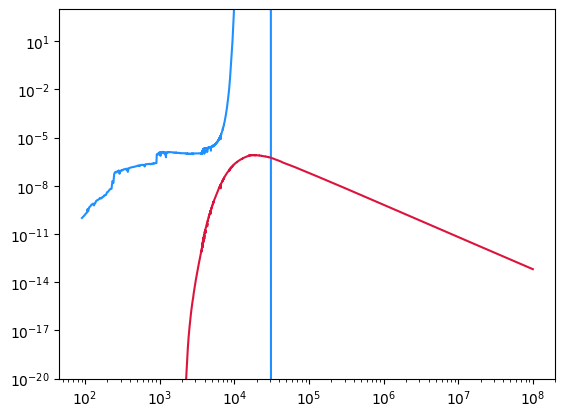

In [674]:
plt.loglog(csp.wave, csp_diff_dust, color = 'dodgerblue')
plt.loglog(wave, spec_fsps_diff_dust, color = 'crimson')
plt.ylim(1e-20, 1e3)


